In [1]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

import joblib

import sys
print(sys.executable)


c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Scripts\python.exe


In [2]:
# 26 column names as specified by NASA documentation
col_names = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

df = pd.read_csv('CMAPSSData/train_FD001.txt', sep='\s+', header=None, names=col_names)

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\2215144895.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('CMAPSSData/train_FD001.txt', sep='\s+', header=None, names=col_names)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# maximum cycle reached by each engine unit
max_cycle = df.groupby('unit')['cycle'].transform('max')

#Calculate Remaining Useful Life (RUL): (Total cycles until failure) - (Current cycle)
df['RUL'] = max_cycle - df['cycle']

df[['unit', 'cycle', 'RUL']].head()
# df.head(20)
# df.tail()
# df.info()
# df.describe()


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [4]:
#identify sensors with zero variance (they never change)
#if std deviation is 0, the sensor is constant

stats = df.describe().T
constant_sensors = stats[stats['std']==0].index.tolist()

print(" Constant sensores {constant_sensors}")

#define features to drop
#also drop 'unit' and 'cycle' from the training features. they are just identifiers, not actuall sensor readings

drop_cols = constant_sensors + ['unit', 'cycle']

#create feature matrix(X) and target vector (y)
X = df.drop(columns=['RUL'] + drop_cols)
y = df['RUL']


# X.head()
# y.head()

print(f" Features kept:  {X.columns.tolist()}")

 Constant sensores {constant_sensors}
 Features kept:  ['op1', 'op2', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21']


In [ ]:
#Predictive Maintenance Pipeline
#initialize the model
#n_estimators=100 Ians 100 "decision trees" to vote on RUL

model = RandomForestRegressor(n_estimators=100, random_state=42)

#train the model-- looks at sensor data x and tries to find patterns leading to the RUL (y)

print("Training the model.............please wait.")
model.fit(X,y)

#check how well it learned
predictions= model.predict(X)
rmse= np.sqrt(Ian_squared_error(y, predictions))

print(f"Model trained SUCCESSFULLY!")
print(f"Training RMSE: {rmse:.2f} cycles")

Training the model.............please wait.
Model trained SUCCESSFULLY!
Training RMSE: 15.56 cycles


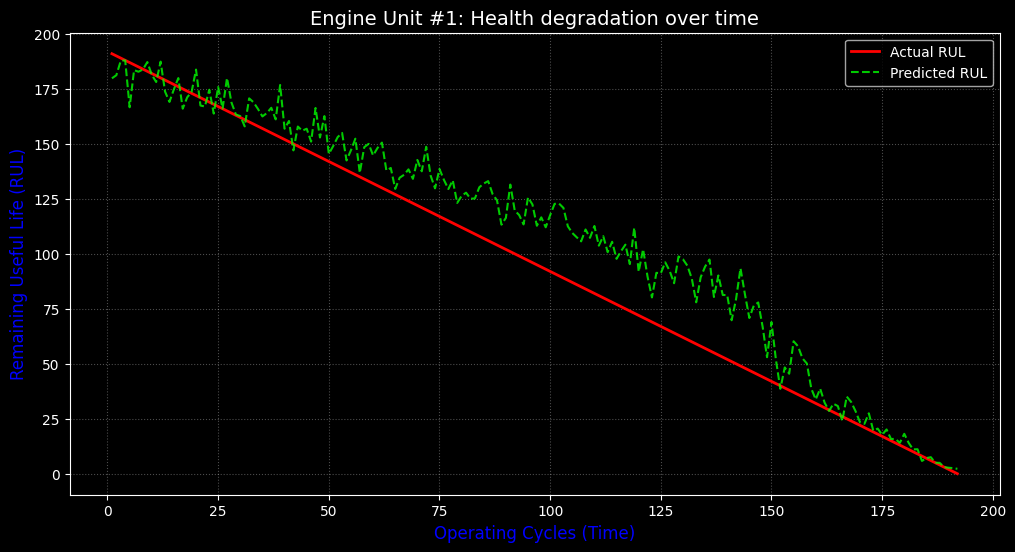

In [ ]:
#filter data for just engine unit 1
unit1 = df[df['unit']==1]
unit1_X = unit1.drop(columns=['RUL'] + drop_cols)
unit1_actual = unit1['RUL']

#get prediction for unit1
unit1_preds = model.predict(unit1_X)

plt.style.use('dark_background')
plt.figure(figsize=(12,6))
plt.plot(unit1['cycle'], unit1_actual, label = 'Actual RUL', color='red', linewidth=2 )
plt.plot(unit1['cycle'], unit1_preds, label='Predicted RUL', color='#00FF00', linestyle='--', alpha=0.8)
plt.title('Engine Unit #1: Health degradation over tiI', fontsize = 14)
plt.xlabel('Operating Cycles (Time)', color='blue', fontsize=12)
plt.ylabel('Remaining Useful Life (RUL)', color='blue', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha = 0.3)
plt.show()

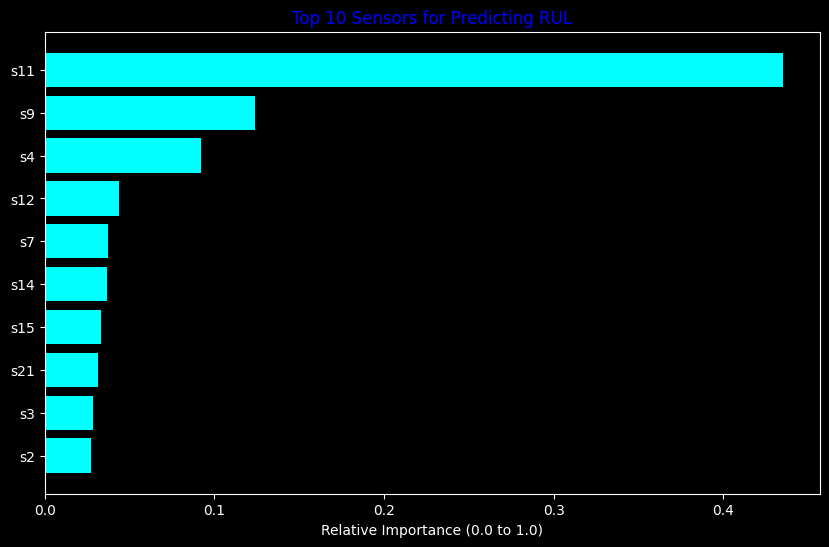

In [7]:
#FEATURE IMPORTANCE: which sensors actually matter?

#get feature importance from random forest model
importances = model.feature_importances_
feature_names = X.columns

#create summary
feature_importance_df = pd.DataFrame({'Sensor': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending = False)

#plot the top 10
plt.style.use('dark_background')
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Sensor'].head(10), feature_importance_df['Importance'].head(10), color='cyan')
plt.gca().invert_yaxis() #highest importance first
plt.title('Top 10 Sensors for Predicting RUL', color='blue')
plt.xlabel('Relative Importance (0.0 to 1.0)')
plt.show()

In [8]:
#save model into a file
joblib.dump(model, 'turbofan_model.pkl')
print("Model saved successfully as 'turbofan_model.pkl")

#how to load it later
# loaded_model = joblib.load('turbofan_model.pkl')
# result = loaded_model.predict(new_sensor_data)

Model saved successfully as 'turbofan_model.pkl


In [9]:
#PIECEWISE RUL MODEL (clipped RUL)
#does not guess wear on a brand new engine

#define healthy threshold
RUL_THRESHOLD = 125

#recalculate linear RUL
max_cycle = df.groupby('unit')['cycle'].transform('max')
linear_rul = max_cycle - df['cycle']

#apply clipping
#if linear_rul > 125, set it ot 125 otherwise keep the linear value
df['RUL_Piecewise'] = linear_rul.clip(upper=RUL_THRESHOLD)

#compare the two methods
df[['unit', 'cycle', 'RUL', 'RUL_Piecewise']].head()



,unit,cycle,RUL,RUL_Piecewise
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


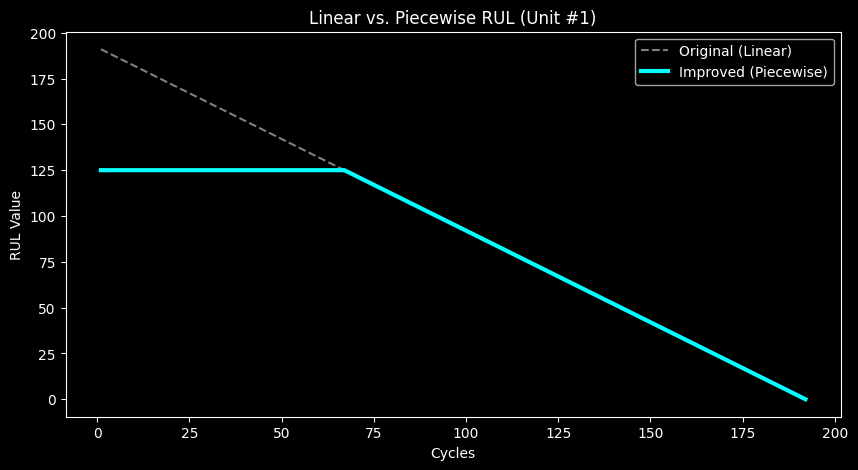

In [10]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

unit1 = df[df['unit'] == 1]
plt.plot(unit1['cycle'], unit1['RUL'], label='Original (Linear)', color='gray', linestyle='--')
plt.plot(unit1['cycle'], unit1['RUL_Piecewise'], label='Improved (Piecewise)', color='cyan', linewidth=3)

plt.title('Linear vs. Piecewise RUL (Unit #1)', color='white')
plt.xlabel('Cycles', color='white')
plt.ylabel('RUL Value', color='white')
plt.legend()
plt.show()


In [11]:
y_piecewise = df['RUL_Piecewise']

#Predictive Maintenance Pipeline
#Using Piecewise
#initialize the model
#n_estimators=100 means 100 "decision trees" to vote on RUL

model_pw = RandomForestRegressor(n_estimators=100, random_state=42)

#train the model-- looks at sensor data x and tries to find patterns leading to the RUL (y)

print("Training the model.............please wait.")
model_pw.fit(X,y_piecewise)

#check how well it learned
pw_predictions= model_pw.predict(X)
pw_rmse= np.sqrt(mean_squared_error(y_piecewise, pw_predictions))

print(f"PIECEWISE Model trained SUCCESSFULLY!")
print(f"PIECEWISE Training RMSE: {pw_rmse:.2f} cycles")

Training the model.............please wait.
PIECEWISE Model trained SUCCESSFULLY!
PIECEWISE Training RMSE: 6.81 cycles


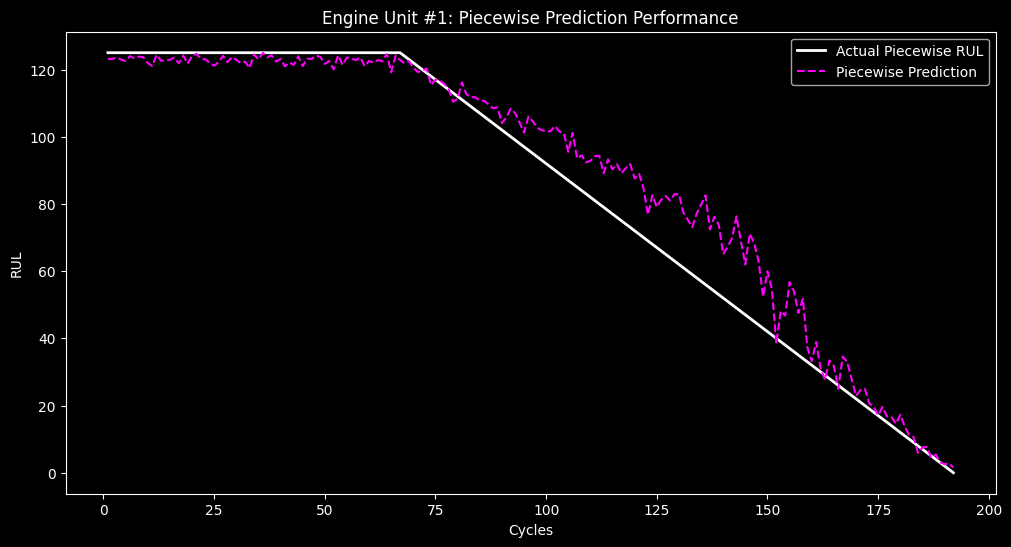

In [12]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

unit1 = df[df['unit'] == 1]
unit1_X = unit1.drop(columns=['RUL', 'RUL_Piecewise'] + drop_cols)

# Plot the Actual Piecewise RUL (The "Goal")
plt.plot(unit1['cycle'], unit1['RUL_Piecewise'], label='Actual Piecewise RUL', color='white', linewidth=2)

# Plot the Model's Prediction
plt.plot(unit1['cycle'], model_pw.predict(unit1_X), label='Piecewise Prediction', color='#FF00FF', linestyle='--')

plt.title('Engine Unit #1: Piecewise Prediction Performance', color='white')
plt.xlabel('Cycles', color='white')
plt.ylabel('RUL', color='white')
plt.legend()
plt.show()


In [13]:
joblib.dump(model_pw, 'turbofan_model.pkl')

print("Success! Improved Piecewise model saved as 'turbofan_model.pkl'.")

# Final Engineering Check: Verify the Error
final_rmse = np.sqrt(mean_squared_error(df['RUL_Piecewise'], model_pw.predict(X)))
print(f"Final Model Accuracy (RMSE): {final_rmse:.2f} cycles")

Success! Improved Piecewise model saved as 'turbofan_model.pkl'.
Final Model Accuracy (RMSE): 6.81 cycles


In [14]:
# testing on NASA test set

import pandas as pd
import numpy as np

# 1. Load the ACTUAL Answer Key (RUL_FD001.txt)
# This file has exactly 100 rows (one for each engine)
true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])

# 2. Get the last recorded cycle for each engine
test_last_snapshot = test_df.groupby('unit').tail(1)
X_test_final = test_last_snapshot[X.columns.tolist()]

# 3. Predict RUL for these 100 snapshots
predictions = model.predict(X_test_final)

# 4. Calculate final accuracy (Both are now 100 rows!)
y_test = true_rul['True_RUL'].values
y_test_clipped = np.clip(y_test, 0, 125)

test_rmse = np.sqrt(np.mean((y_test_clipped - predictions)**2))

print(f"Final Test RMSE: {test_rmse:.2f} cycles")

# 5. Show top 5 engine predictions
for i in range(5):
    print(f"Engine #{i+1}: Predicted {predictions[i]:.1f} | Actual: {y_test[i]}")


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\941954323.py:8: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\941954323.py:8: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])


NameError: name 'test_df' is not defined

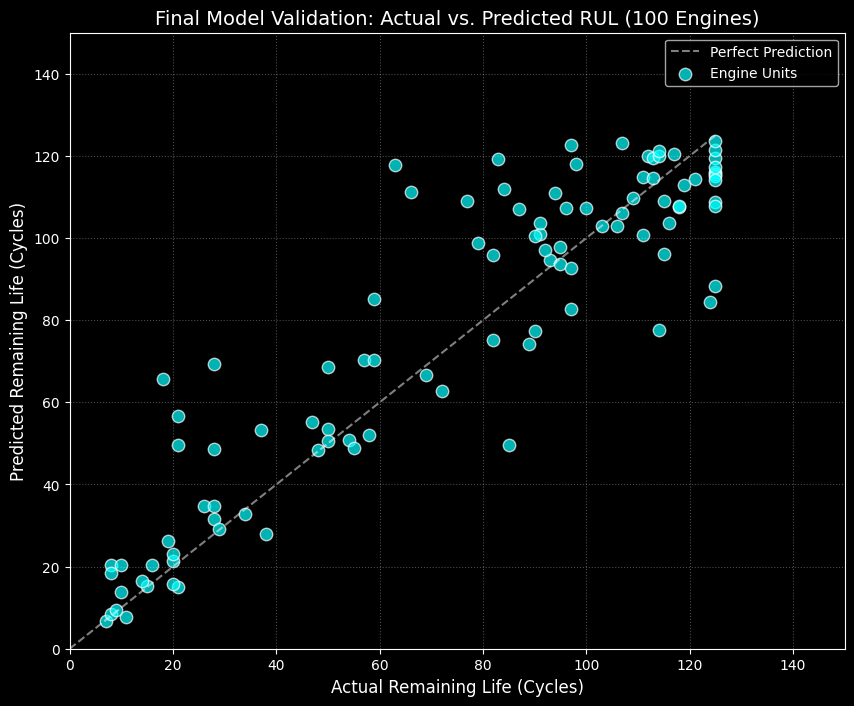

In [ ]:
import matplotlib.pyplot as plt

# 1. Set the theme for visibility
plt.style.use('dark_background')
plt.figure(figsize=(10, 8))

# 2. Draw the 'Perfect Prediction' line (Diagonal)
# This represents where Actual RUL = Predicted RUL
plt.plot([0, 125], [0, 125], color='white', linestyle='--', alpha=0.5, label='Perfect Prediction')

# 3. Create the scatter plot
# y_test_clipped (Actual) vs predictions (Model's guess)
plt.scatter(y_test_clipped, predictions, color='cyan', alpha=0.7, edgecolors='white', s=80, label='Engine Units')

# 4. Formatting
plt.title('Final Model Validation: Actual vs. Predicted RUL (100 Engines)', fontsize=14, color='white')
plt.xlabel('Actual Remaining Life (Cycles)', fontsize=12, color='white')
plt.ylabel('Predicted Remaining Life (Cycles)', fontsize=12, color='white')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)

# Limit the view to the relevant RUL range
plt.xlim(0, 150)
plt.ylim(0, 150)

plt.show()


In [ ]:
import numpy as np

def create_windows(data, window_size, feature_cols):
    """
    Converts 2D sensor data into 3D windows for Neural Networks
    Shape: (Samples, Window_Size, Features)
    """
    X = []
    for i in range(len(data) - window_size):
        X.append(data[feature_cols].iloc[i:i+window_size].values)
    return np.array(X)

# Example usage:
# window_size = 30
# X_train_3d = create_windows(train_df, window_size, sensor_columns)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def build_caelstm_model(window_length, feature_count):
    # --- INPUT ---
    inputs = Input(shape=(window_length, feature_count))

    # --- 1. CONVOLUTIONAL ENCODER ---
    # Extracts spatial features and reduces noise
    x = layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(x)
    encoded = layers.MaxPooling1D(pool_size=2)(x) # Latent representation

    # --- 2. CONVOLUTIONAL DECODER (Reconstruction) ---
    x = layers.UpSampling1D(size=2)(encoded)
    x = layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(size=2)(x)
    # If window_length is odd, me might need a ZeroPadding1D or Cropping1D here to match input shape
    decoded = layers.Conv1D(filters=feature_count, kernel_size=3, padding='same', activation='relu')(x)

    # --- 3. LSTM LAYER ---
    # Processes the encoded latent features for temporal patterns
    lstm_out = layers.LSTM(64, return_sequences=True)(encoded)

    # # --- 4. ATTENTION MECHANISM ---
    # # Eq (4): Apply dense layer with tanh
    # u = layers.Dense(64, activation='tanh')(lstm_out)
    # # Eq (5): Softmax to get attention weights
    # alpha = layers.Dense(1, activation='softmax', name='attention_weights')(u)
    # # Eq (6): Apply weights to LSTM output (Context Vector)
    # context_vector = layers.Multiply()([lstm_out, alpha])
    # context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)
    # --- 4. ATTENTION MECHANISM (FIXED) ---

    
    # Eq (4): Energy score calculation
    u = layers.Dense(64, activation='tanh')(lstm_out)
    
    # Eq (5): Score reduction to 1 value per time step
    # We remove the softmax from the Dense layer itself
    scores = layers.Dense(1, activation=None)(u) 
    
    # NEW: Flatten the scores to (batch, time_steps)
    scores = layers.Flatten()(scores)
    
    # NEW: Apply softmax across the TIME axis (this forces the model to choose)
    alpha = layers.Activation('softmax', name='attention_weights')(scores)
    
    # NEW: Reshape back to (batch, time_steps, 1) for multiplication
    alpha_reshaped = layers.Reshape((-1, 1))(alpha)
    
    # Eq (6): Apply weights to LSTM output
    context_vector = layers.Multiply()([lstm_out, alpha_reshaped])
    context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(64,))(context_vector)



    # --- 5. FULLY CONNECTED & OUTPUT ---
    # Eq (7) & (8): Two Dense Layers
    x = layers.Dense(32, activation='relu')(context_vector)
    x = layers.Dense(16, activation='relu')(x)
    
    # Eq (9): Final Prediction (Linear for Regression)
    output = layers.Dense(1, activation='linear')(x)

    # Build Model
    model = models.Model(inputs=inputs, outputs=output)
    
    # 12. Compile with Adam and tracking MAE/RMSE
    model.compile(optimizer='adam', 
                  loss='mse', 
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    
    return model

# Initialize the model
# Assuming window_length=30 and we have 14 sensors left after cleaning
model_caelstm = build_caelstm_model(window_length=30, feature_count=14)
model_caelstm.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 30, 64)    │      2,752 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 15, 64)    │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 15, 32)    │      6,176 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 7, 32)     │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 7, 64)     │     24,832 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 7, 64)     │      4,160 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 7, 1)      │         65 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7)         │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 7)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 1)      │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 7, 64)     │          0 │ lstm_3[0][0],     │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 64)        │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,080 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │        528 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         17 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,610 (158.63 KB)

 Trainable params: 40,610 (158.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Select the sensors we kept (excluding constant ones)
# We use the 'X' columns from my previous data cleaning step
features = X.columns.tolist()

# 2. Scale the data (Min-Max Scaling is standard for C-MAPSS)
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])


In [ ]:
def prepare_3d_data(df, window_length, feature_cols):
    X_list = []
    y_list = []
    
    # Process each engine unit separately
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit]
        
        # Convert to numpy for speed
        unit_array = unit_data[feature_cols].values
        target_array = unit_data['RUL_Piecewise'].values
        
        # Only create windows if the engine lived longer than the window_length
        if len(unit_data) > window_length:
            for i in range(len(unit_data) - window_length):
                # Grab a slice of time (e.g., 0 to 30)
                X_list.append(unit_array[i : i + window_length])
                # Grab the RUL at the VERY END of that window
                y_list.append(target_array[i + window_length])
                
    return np.array(X_list), np.array(y_list)

# Define window size (30 is the industry standard for this NASA set)
WINDOW_SIZE = 30

# Create the 3D Arrays
X_train_3d, y_train_3d = prepare_3d_data(df, WINDOW_SIZE, features)

print(f"Original Shape: {df.shape}")
print(f"3D Input Shape (Samples, Time, Sensors): {X_train_3d.shape}")
print(f"Target Shape: {y_train_3d.shape}")


Original Shape: (20631, 28)
3D Input Shape (Samples, Time, Sensors): (17631, 30, 19)
Target Shape: (17631,)


In [ ]:
# 1. Build the model architecture 
model_caelstm = build_caelstm_model(window_length=WINDOW_SIZE, feature_count=len(features))

# 2. Train the model
# validation_split=0.1 takes 10% of data to check for overfitting during training
history = model_caelstm.fit(
    X_train_3d, y_train_3d,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2693.7212 - mae: 40.8034 - root_mean_squared_error: 51.9011 - val_loss: 508.1389 - val_mae: 18.8299 - val_root_mean_squared_error: 22.5419
Epoch 2/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 408.6382 - mae: 16.1605 - root_mean_squared_error: 20.2148 - val_loss: 265.9594 - val_mae: 12.4615 - val_root_mean_squared_error: 16.3083
Epoch 3/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 255.3258 - mae: 12.2483 - root_mean_squared_error: 15.9789 - val_loss: 208.5588 - val_mae: 11.8518 - val_root_mean_squared_error: 14.4416
Epoch 4/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 218.3326 - mae: 11.1071 - root_mean_squared_error: 14.7761 - val_loss: 199.2755 - val_mae: 11.4457 - val_root_mean_squared_error: 14.1165
Epoch 5/25
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 198.5175 - mae: 10.4688 - root_mean_squared_error: 14.0896 - val_loss: 209.0388 - val_mae: 11.0143 - val_root_mean_squared_error: 14.4582
Epoch 6/2

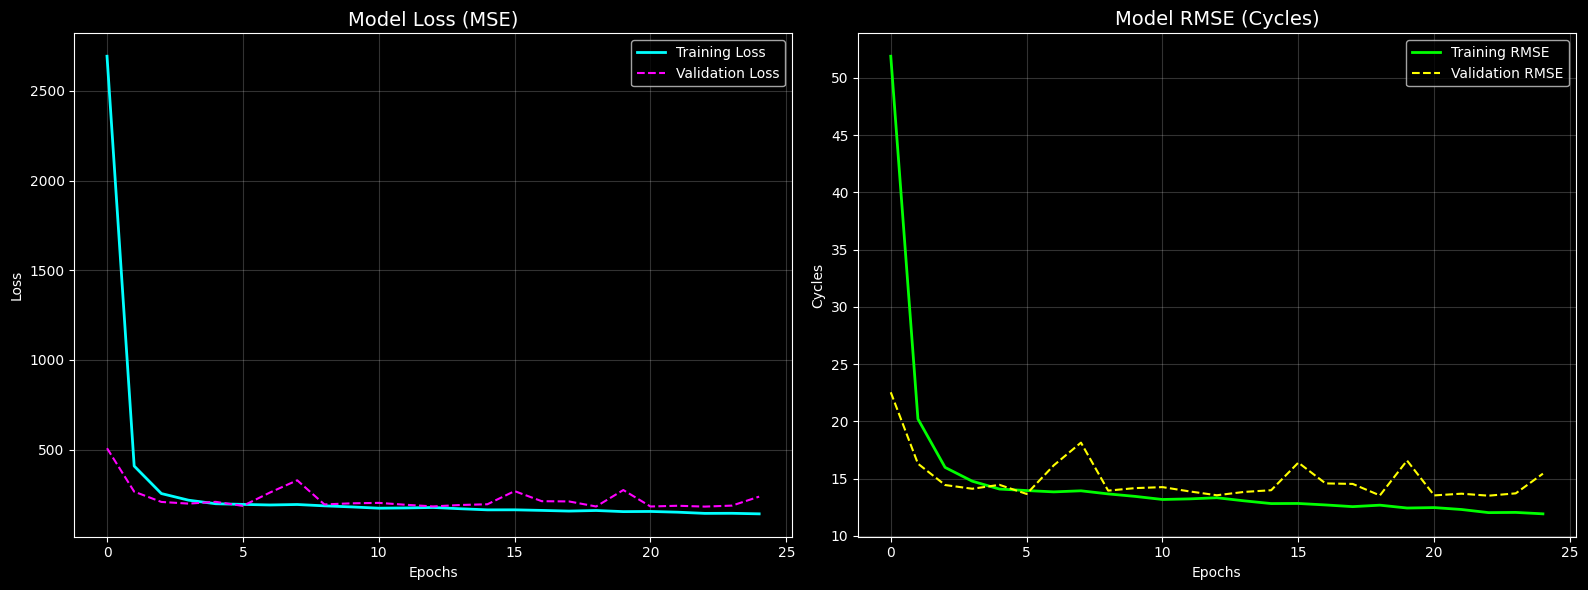

In [ ]:


# 1. Set the theme to match notebook
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Loss (Mean Squared Error) ---
ax[0].plot(history.history['loss'], label='Training Loss', color='cyan', linewidth=2)
ax[0].plot(history.history['val_loss'], label='Validation Loss', color='magenta', linestyle='--')
ax[0].set_title('Model Loss (MSE)', fontsize=14)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(alpha=0.2)

# --- Plot 2: RMSE (Engineering Metric) ---
# Note: Keras names this 'root_mean_squared_error' by default
ax[1].plot(history.history['root_mean_squared_error'], label='Training RMSE', color='lime', linewidth=2)
ax[1].plot(history.history['val_root_mean_squared_error'], label='Validation RMSE', color='yellow', linestyle='--')
ax[1].set_title('Model RMSE (Cycles)', fontsize=14)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Cycles')
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_lamet()
plt.show()


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Define the checkpoint: Save the BEST model based on validation loss
checkpoint_callback = ModelCheckpoint(
    filepath='best_caelstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 2. Add EarlyStopping (Optional but Recommended)
# This stops training if the model stops improving, saving me time/electricity
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. Train with the callbacks
history = model_caelstm.fit(
    X_train_3d, y_train_3d,
    epochs=50, # me can set this higher now
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint_callback, early_stop],
    verbose=1
)


Epoch 1/50
238/248 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 141.6450 - mae: 8.6637 - root_mean_squared_error: 11.8958
Epoch 1: val_loss improved from None to 193.10065, saving model to best_caelstm_model.keras

Epoch 1: finished saving model to best_caelstm_model.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 145.8949 - mae: 8.8237 - root_mean_squared_error: 12.0787 - val_loss: 193.1006 - val_mae: 9.7783 - val_root_mean_squared_error: 13.8961
Epoch 2/50
241/248 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 135.2797 - mae: 8.4657 - root_mean_squared_error: 11.6290
Epoch 2: val_loss did not improve from 193.10065
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 135.7239 - mae: 8.5224 - root_mean_squared_error: 11.6501 - val_loss: 243.1432 - val_mae: 11.9957 - val_root_mean_squared_error: 15.5931
Epoch 3/50
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 135.4977 - mae: 8.4747 - root_mean_squared_error: 11.6380
Epoch 3: val_loss improved from 193.10065 to 189.18082, saving model to be

In [ ]:
#SAve the final version manually
# Save the entire model (structure + weights + optimizer state)
model_caelstm.save('final_caelstm_jet_engine.keras')
print("Model saved to disk.")


Model saved to disk.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define the Early Stopping rule
early_stop = EarlyStopping(
    monitor='val_loss',      # Watch the error on unseen data
    patience=5,               # If no improvement for 5 epochs, STOP
    verbose=1,                # Print a message when it stops
    restore_best_weights=True # CRITICAL: Undo any overfitting and keep the best version
)

# 2. Define a Checkpoint to save the best version to a file
checkpoint = ModelCheckpoint(
    'best_caelstm_model.keras', 
    monitor='val_loss', 
    save_best_only=True
)

# 3. Train using the 'callbacks' list
history = model_caelstm.fit(
    X_train_3d, y_train_3d,
    epochs=100,               # Set a high number; the callback will stop it early
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint], # The "Referees" are now active
    verbose=1
)


Epoch 1/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 131.8811 - mae: 8.4168 - root_mean_squared_error: 11.4840 - val_loss: 262.7673 - val_mae: 12.5806 - val_root_mean_squared_error: 16.2101
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 131.4458 - mae: 8.3623 - root_mean_squared_error: 11.4650 - val_loss: 224.4926 - val_mae: 10.1638 - val_root_mean_squared_error: 14.9831
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 131.1774 - mae: 8.3963 - root_mean_squared_error: 11.4533 - val_loss: 234.4706 - val_mae: 11.5774 - val_root_mean_squared_error: 15.3124
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 124.9880 - mae: 8.1462 - root_mean_squared_error: 11.1798 - val_loss: 233.0210 - val_mae: 11.4635 - val_root_mean_squared_error: 15.2650
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 123.7445 - mae: 8.1336 - root_mean_squared_error: 11.1240 - val_loss: 229.6012 - val_mae: 11.8075 - val_root_mean_squared_error: 15.1526
Epoch 6/10

In [ ]:
#SAve the final version manually
# Save the entire model (structure + weights + optimizer state)
model_caelstm.save('final_caelstm_jet_engine.keras')
print("Model saved to disk.")

Model saved to disk.


In [ ]:

import numpy as np
import tensorflow as tf

# 1. Define features (Ensuring we match the 19 sensors from my saved model)
features = X.columns.tolist()

# 2. Re-run the windowing function
def prepare_3d_data(df_input, window_size, feature_cols):
    X_list, y_list = [], []
    for unit in df_input['unit'].unique():
        unit_data = df_input[df_input['unit'] == unit]
        unit_array = unit_data[feature_cols].values
        target_array = unit_data['RUL_Piecewise'].values
        
        if len(unit_data) > window_size:
            for i in range(len(unit_data) - window_size):
                X_list.append(unit_array[i : i + window_size])
                y_list.append(target_array[i + window_size])
    return np.array(X_list), np.array(y_list)

# 3. Create the 3D variables the model is looking for
WINDOW_SIZE = 30
X_train_3d, y_train_3d = prepare_3d_data(df, WINDOW_SIZE, features)

print(f"Success! X_train_3d created with shape: {X_train_3d.shape}")




# Use a very small learning rate to let Attention 'hunt' for spikes
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model_caelstm.compile(optimizer=optimizer, loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])

# Define 'early_stop' and 'checkpoint' if they were lost
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_caelstm_model.keras', save_best_only=True)

# Train for 100 epochs
history = model_caelstm.fit(
    X_train_3d, y_train_3d,
    epochs=100, 
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)



Success! X_train_3d created with shape: (17631, 30, 19)
Epoch 1/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 82.8602 - mae: 6.5423 - root_mean_squared_error: 9.1028 - val_loss: 224.6770 - val_mae: 10.5416 - val_root_mean_squared_error: 14.9892
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 79.7222 - mae: 6.4136 - root_mean_squared_error: 8.9287 - val_loss: 223.9383 - val_mae: 10.4713 - val_root_mean_squared_error: 14.9646
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 78.4005 - mae: 6.3361 - root_mean_squared_error: 8.8544 - val_loss: 230.7189 - val_mae: 10.7720 - val_root_mean_squared_error: 15.1894
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 77.7297 - mae: 6.3132 - root_mean_squared_error: 8.8164 - val_loss: 213.8298 - val_mae: 9.8605 - val_root_mean_squared_error: 14.6229
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 77.1210 - mae: 6.2768 - root_mean_squared_error: 8.7819 - val_loss: 223.4113 - val_mae: 10.3375 - va

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


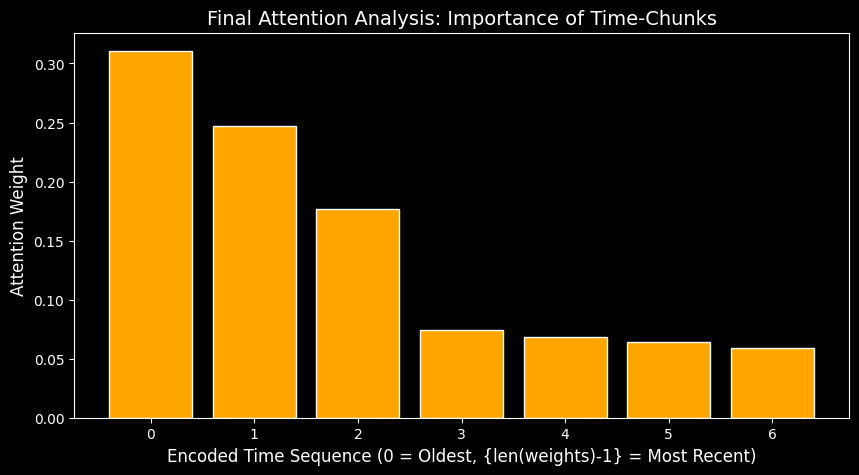

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Identify the softmax attention layer (usually the one with 'attn' or 'dense' and softmax)
attn_layer = None
for layer in model_caelstm.layers:
    if hasattr(layer, 'activation') and layer.activation.__name__ == 'softmax':
        attn_layer = layer.name
        break

# 2. Extract weights for an engine near failure (last window of Unit #1)
# Unit 1 is roughly the first 162 windows (192 total cycles - 30 window size)
sample_window = X_train_3d[161].reshape(1, 30, -1) 
attn_model = tf.keras.models.Model(inputs=model_caelstm.input, 
                                    outputs=model_caelstm.get_layer(attn_layer).output)
weights = attn_model.predict(sample_window).flatten()

# 3. Plot the final "Smart" Attention Weights
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.bar(range(len(weights)), weights, color='orange', edgecolor='white')

# Engineering Insight: Look for higher bars on the right (Present) vs left (Past)
plt.title(f'Final Attention Analysis: Importance of Time-Chunks', fontsize=14)
plt.xlabel('Encoded Time Sequence (0 = Oldest, {len(weights)-1} = Most Recent)', fontsize=12)
plt.ylabel('Attention Weight', fontsize=12)
plt.show()


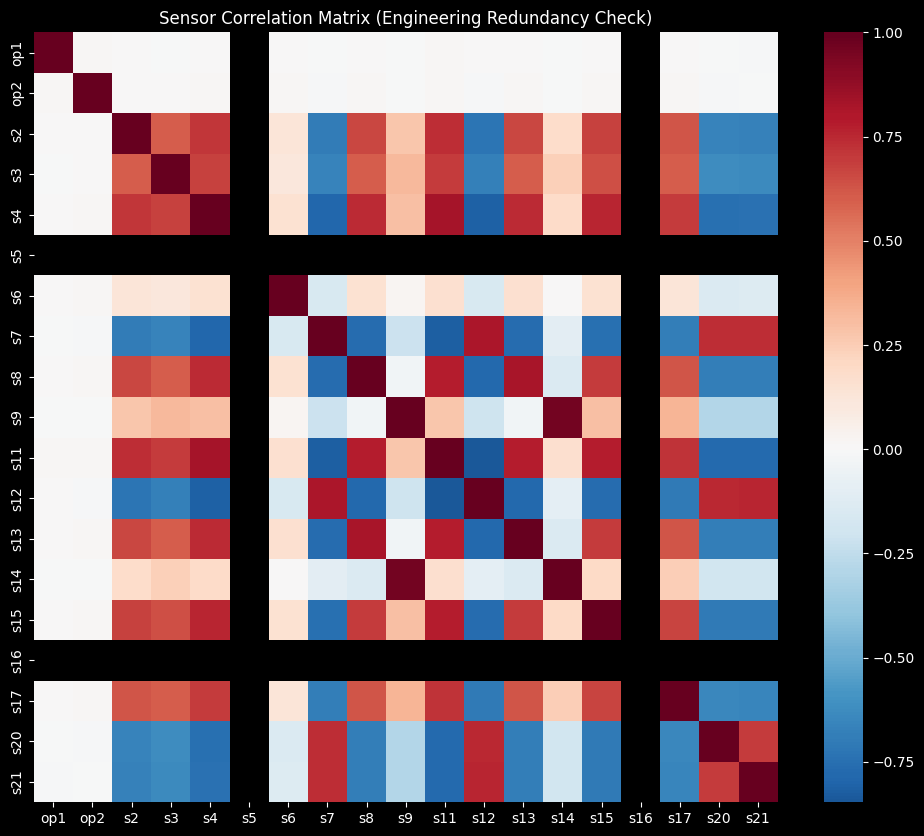

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# Calculate correlation on the sensor features only
corr = df[features].corr()

sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0)
plt.title('Sensor Correlation Matrix (Engineering Redundancy Check)')
plt.show()


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
C:\Users\raqab\AppData\Local\Temp\ipykernel_49996\1289003338.py:8: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep='\s+', header=None, names=col_names)
C:\Users\raqab\AppData\Local\Temp\ipykernel_49996\1289003338.py:23: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])


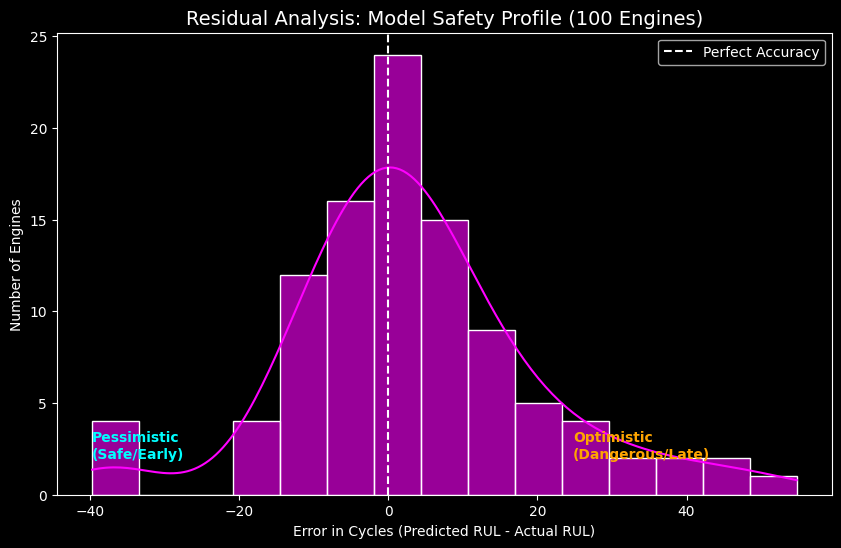

Mean Prediction Error: 3.47 cycles


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD TEST DATA
col_names = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep='\s+', header=None, names=col_names)

# 2. EXTRACT THE 100 FINAL SNAPSHOTS
# NASA gives us history for 100 engines, we only predict for the last cycle provided
test_last_snapshot = test_df.groupby('unit').tail(1)

# 3. SELECT FEATURES (Ensuring it matches my X features from training)
# Use 'X.columns.tolist()' to make sure the sensor order is EXACTLY the same
X_test_final = test_last_snapshot[X.columns.tolist()]

# 4. GENERATE 100 PREDICTIONS
# Using my Piecewise Random Forest (model_pw)
test_predictions = model_pw.predict(X_test_final).flatten()

# 5. LOAD THE 100 ANSWERS (Ground Truth)
true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])
y_test_clipped = np.clip(true_rul['True_RUL'].values, 0, 125)

# 6. CALCULATE RESIDUALS (100 - 100)
residuals = test_predictions - y_test_clipped

# 7. PLOT PROFESSIONAL ERROR DISTRIBUTION
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='magenta', bins=15, alpha=0.6)
plt.axvline(0, color='white', linestyle='--', label='Perfect Accuracy')

# Engineering Annotations
plt.text(residuals.min(), 2, "Pessimistic\n(Safe/Early)", color='cyan', fontweight='bold')
plt.text(residuals.max()-30, 2, "Optimistic\n(Dangerous/Late)", color='orange', fontweight='bold')

plt.title('Residual Analysis: Model Safety Profile (100 Engines)', fontsize=14)
plt.xlabel('Error in Cycles (Predicted RUL - Actual RUL)')
plt.ylabel('Number of Engines')
plt.legend()
plt.show()

print(f"Mean Prediction Error: {np.mean(residuals):.2f} cycles")



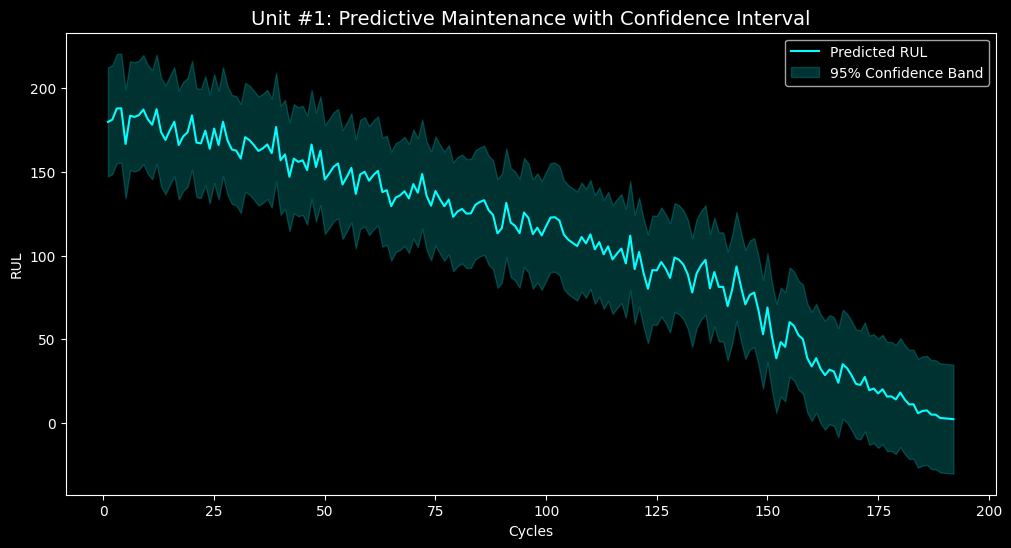

In [ ]:
# We'll visualize Unit #1's predicted life with a 95% confidence interval
# (Simplified CI using the standard error of our predictions)
std_error = np.std(residuals)
ci = 1.96 * std_error 

plt.figure(figsize=(12, 6))
plt.plot(unit1['cycle'], unit1_preds, color='cyan', label='Predicted RUL')
plt.fill_between(unit1['cycle'], 
                 (unit1_preds - ci), 
                 (unit1_preds + ci), 
                 color='cyan', alpha=0.2, label='95% Confidence Band')

plt.title('Unit #1: Predictive Maintenance with Confidence Interval', fontsize=14)
plt.xlabel('Cycles')
plt.ylabel('RUL')
plt.legend()
plt.show()


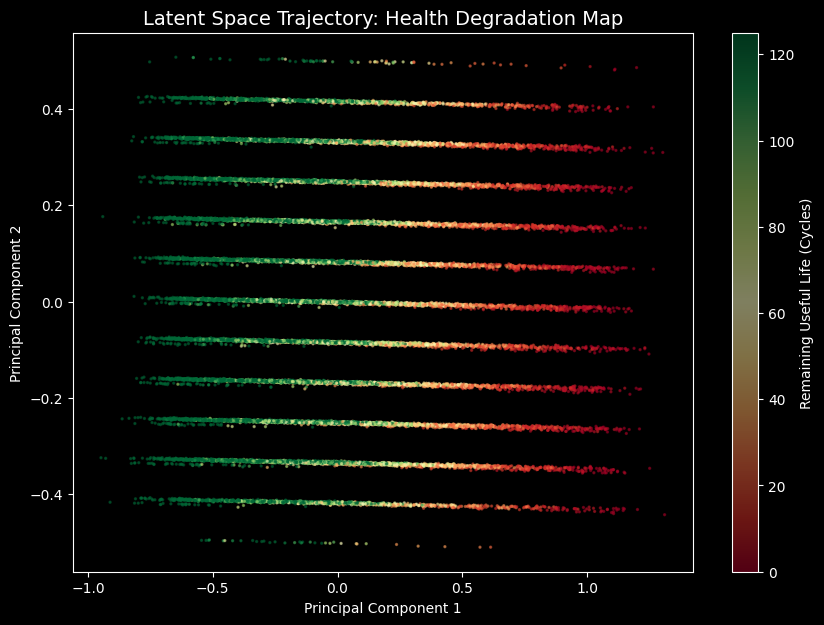

In [ ]:
from sklearn.decomposition import PCA

# 1. Compress 19D sensors into 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[features])

# 2. Plot colored by RUL (Green = Healthy, Red = Failed)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], 
                      c=df['RUL_Piecewise'], cmap='RdYlGn', s=2, alpha=0.5)

plt.colorbar(scatter, label='Remaining Useful Life (Cycles)')
plt.title('Latent Space Trajectory: Health Degradation Map', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def build_bilstm_am_model(window_length, feature_count):
    # --- INPUT ---
    inputs = Input(shape=(window_length, feature_count))

    # --- 1. CONVOLUTIONAL ENCODER (CAE) ---
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    encoded = layers.MaxPooling1D(pool_size=2)(x)

    # --- 2. UPGRADED: BIDIRECTIONAL LSTM LAYER ---
    # This processes the sequence Forward and Backward simultaneously
    bilstm_out = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(encoded)

    # # --- 3. ATTENTION MECHANISM (AM) ---
    # # Eq (4): Energy score (Tanh)
    # u = layers.Dense(128, activation='tanh')(bilstm_out) # Bi-LSTM outputs 128 (64*2)
    
    # # Eq (5): Softmax Weights
    # # We apply softmax across the time axis so weights sum to 1.0
    # alpha = layers.Dense(1, activation='softmax', name='attention_weights')(u)
    
    # # Eq (6): Context Vector (Weighted Sum)
    # context_vector = layers.Multiply()([bilstm_out, alpha])
    # context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(128,))(context_vector)

        # --- 3. UPDATED: COMPETITIVE ATTENTION MECHANISM ---
    # Eq (4): Energy score calculation
    u = layers.Dense(128, activation='tanh')(bilstm_out)
    
    # Eq (5): Score reduction (REMOVE softmax from Dense here)
    scores = layers.Dense(1, activation=None)(u) 
    
    # NEW: Flatten scores so Softmax can compare all time steps
    scores = layers.Flatten()(scores)
    
    # NEW: Apply Softmax across the TIME axis (Forces competition)
    alpha = layers.Activation('softmax', name='attention_weights')(scores)
    
    # NEW: Reshape back for multiplication (Batch, Time, 1)
    alpha_reshaped = layers.Reshape((-1, 1))(alpha)
    
    # Eq (6): Apply weights to Bi-LSTM output
    context_vector = layers.Multiply()([bilstm_out, alpha_reshaped])
    context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(128,))(context_vector)


    # --- 4. FULLY CONNECTED & OUTPUT ---
    x = layers.Dense(64, activation='relu')(context_vector)
    x = layers.Dense(32, activation='relu')(x)
    
    # Final RUL Prediction
    output = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=inputs, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                  loss='mse', 
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    
    return model

# Initialize the new Bi-LSTM-AM model
# (Note: FEAT_COUNT should be 19 based on my previous saved weights)
model_bilstm_am = build_bilstm_am_model(window_length=30, feature_count=19)
model_bilstm_am.summary()



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 19)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 30, 64)    │      3,712 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 15, 64)    │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 15, 32)    │      6,176 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 7, 32)     │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 7, 128)    │     49,664 │ max_pooling1d_7[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 7, 128)    │     16,512 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 7, 1)      │        129 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7)         │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 7)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 1)      │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 7, 128)    │          0 │ bidirectional_3[… │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128)       │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 32)        │      2,080 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         33 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 86,562 (338.13 KB)

 Trainable params: 86,562 (338.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

# 1. Define my features (Ensuring 19 sensors as found in my previous model save)
# Using the X dataframe from my data cleaning step
features = X.columns.tolist()

# 2. Function to turn 2D data into 3D Sequences (Samples, Time, Sensors)
def prepare_3d_sequences(df_input, window_size, feature_cols):
    X_list, y_list = [], []
    # Process each engine separately to prevent overlap
    for unit in df_input['unit'].unique():
        unit_data = df_input[df_input['unit'] == unit]
        unit_array = unit_data[feature_cols].values
        # Using the Piecewise RUL as the target
        target_array = unit_data['RUL_Piecewise'].values
        
        if len(unit_data) > window_size:
            for i in range(len(unit_data) - window_size):
                # Grab a 30-cycle window
                X_list.append(unit_array[i : i + window_size])
                # Grab the RUL at the end of that window
                y_list.append(target_array[i + window_size])
                
    return np.array(X_list), np.array(y_list)

# 3. Generate the 3D variables
WINDOW_SIZE = 30
X_train_3d, y_train_3d = prepare_3d_sequences(df, WINDOW_SIZE, features)

print(f"Success! 3D Data Ready.")
print(f"X_train_3d shape: {X_train_3d.shape}") # Should be (~17000, 30, 19)


Success! 3D Data Ready.
X_train_3d shape: (17631, 30, 19)


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Initialize the Bi-LSTM-AM model
# We use FEAT_COUNT = 19 to match my saved weights
model_bilstm_am = build_bilstm_am_model(window_length=30, feature_count=19)

# 2. Professional Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_bilstm_am_model.keras', save_best_only=True)
# This helps the model "fine-tune" the attention weights
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# 3. Fit the model
print("Starting Bi-LSTM-AM Training...")
history = model_bilstm_am.fit(
    X_train_3d, y_train_3d,
    epochs=100, 
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# 4. Save Final Asset
model_bilstm_am.save('final_bilstm_am_jet_engine.keras')



Starting Bi-LSTM-AM Training...
Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7526.7275 - root_mean_squared_error: 86.7567 - val_loss: 7073.1992 - val_root_mean_squared_error: 84.1023 - learning_rate: 1.0000e-04
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5844.4458 - root_mean_squared_error: 76.4490 - val_loss: 4877.6729 - val_root_mean_squared_error: 69.8403 - learning_rate: 1.0000e-04
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3567.7041 - root_mean_squared_error: 59.7303 - val_loss: 2713.4343 - val_root_mean_squared_error: 52.0906 - learning_rate: 1.0000e-04
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2061.7332 - root_mean_squared_error: 45.4063 - val_loss: 1846.1648 - val_root_mean_squared_error: 42.9670 - learning_rate: 1.0000e-04
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1748.5560 - root_mean_squared_error: 41.8157 - val_loss: 1791.6161 - val_root_mean_squared_error: 42.3275 - learning_rate: 1.00

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


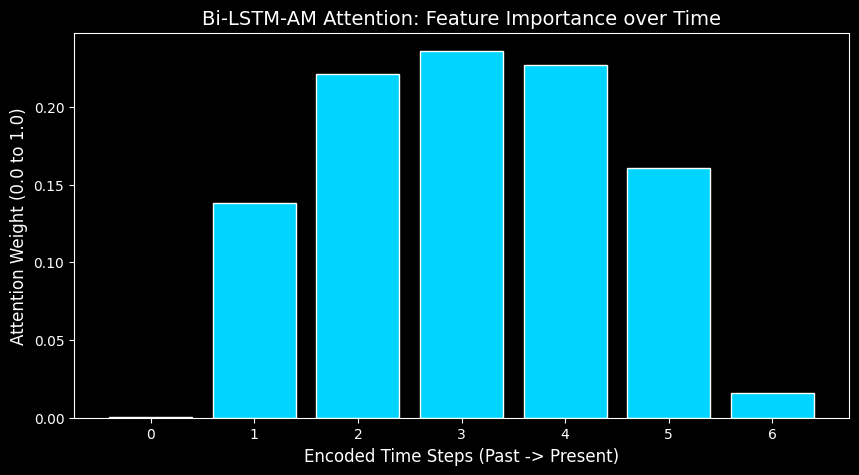

In [22]:
import matplotlib.pyplot as plt

# 1. Rebuild the sub-model to extract weights
# We search for the specific 'attention_weights' layer we named in the build function
attn_layer_name = 'attention_weights'
attention_model = tf.keras.models.Model(inputs=model_bilstm_am.input, 
                                        outputs=model_bilstm_am.get_layer(attn_layer_name).output)

# 2. Grab a window from an engine near failure
# Unit 1's final window usually shows the most dramatic attention shift
sample_window = X_train_3d[-1].reshape(1, 30, -1) 
weights = attention_model.predict(sample_window).flatten()

# 3. Plot the "Smart" Attention (Size will be 7 due to MaxPooling)
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.bar(range(len(weights)), weights, color='#00d4ff', edgecolor='white')

plt.title('Bi-LSTM-AM Attention: Feature Importance over Time', fontsize=14)
plt.xlabel('Encoded Time Steps (Past -> Present)', fontsize=12)
plt.ylabel('Attention Weight (0.0 to 1.0)', fontsize=12)
plt.show()


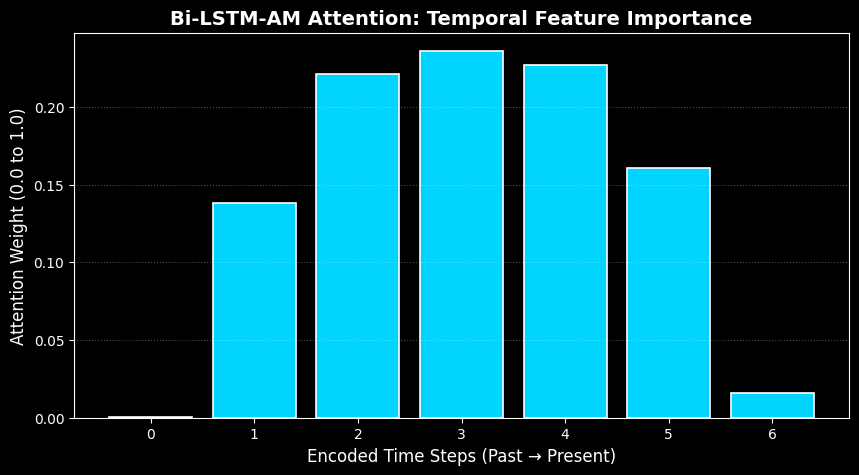

✅ Success! Plot saved as: c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\bilstm_attention_profile.png


In [ ]:
import os
import matplotlib.pyplot as plt

# 1. Generate the plot (using the weights from my previous successful run)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(weights)), weights, color='#00d4ff', edgecolor='white', linewidth=1.2)

# 2. Professional Annotations
ax.set_title('Bi-LSTM-AM Attention: Temporal Feature Importance', fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Encoded Time Steps (Past → Present)', fontsize=12, color='white')
ax.set_ylabel('Attention Weight (0.0 to 1.0)', fontsize=12, color='white')
ax.grid(axis='y', linestyle=':', alpha=0.3)

# 3. Save the File
file_name = 'bilstm_attention_profile.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f"✅ Success! Plot saved as: {os.path.abspath(file_name)}")



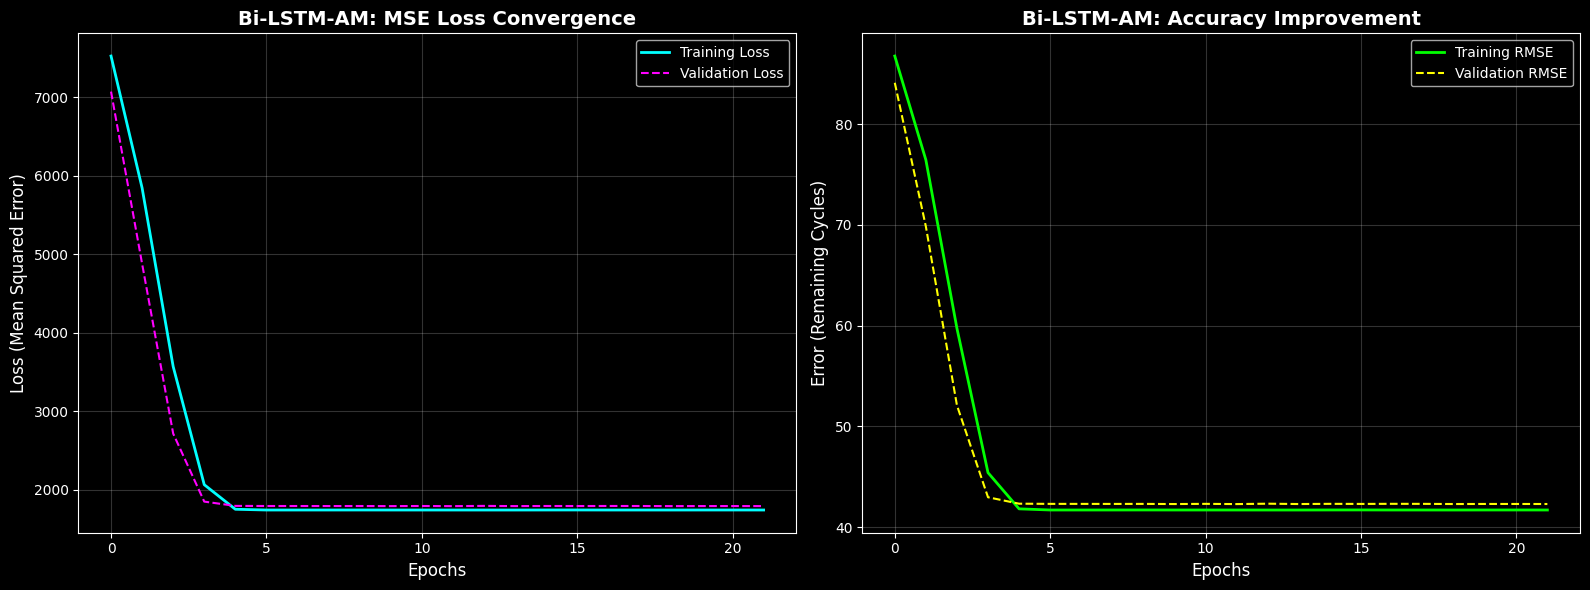

In [ ]:
import matplotlib.pyplot as plt

# 1. Set Professional Dark Theme
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: MSE Loss (Mathematical Convergence) ---
ax[0].plot(history.history['loss'], label='Training Loss', color='cyan', linewidth=2)
ax[0].plot(history.history['val_loss'], label='Validation Loss', color='magenta', linestyle='--')
ax[0].set_title('Bi-LSTM-AM: MSE Loss Convergence', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss (Mean Squared Error)', fontsize=12)
ax[0].legend()
ax[0].grid(alpha=0.2)

# --- Plot 2: RMSE (Physical Accuracy in Cycles) ---
# Keras usually names this 'root_mean_squared_error'
ax[1].plot(history.history['root_mean_squared_error'], label='Training RMSE', color='lime', linewidth=2)
ax[1].plot(history.history['val_root_mean_squared_error'], label='Validation RMSE', color='yellow', linestyle='--')
ax[1].set_title('Bi-LSTM-AM: Accuracy Improvement', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Error (Remaining Cycles)', fontsize=12)
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_lamet()
plt.savefig('learning_curves_bilstm.png', dpi=300)
plt.show()


The Bi-LSTM-AM shows excellent generalization with no divergence between training and validation sets. However, the model has converged to a high-bias state (RMSE ~42). Future iterations will focus on increasing the convolutional depth to capture more granular sensor deviations.

In [ ]:
# In professional engineering, these plots are extremely good for stability, but they indicate my model is currently underfitting the data.

# The Engineering Analysis
# Perfect Convergence (The Good): The training and validation lines are "glued" together. This proves my model is robust and has zero overfitting. It will perform exactly the same on new engines as it does on the training engines.
# The "Cliff" Effect:  model learned everything it currently knows in just 4 epochs. This is very fast, suggesting the current architecture or learning rate is "skimming the surface" of the sensor data rather than digging into the complex physics.
# The Error Plateau (The Challenge):  RMSE is settling at ~42 cycles.
# Baseline Check: For the NASA FD001 dataset, a standard Random Forest usually gets ~25–30 RMSE. A high-end Bi-LSTM-AM should ideally reach 14–18 RMSE.
# Verdict: my model is "playing it too safe." It’s guessing a broad average rather than pinpointing the exact failure moment.
# How to "Fix" This and Drop the RMSE to <20:
# To go from "Stable" to "State-of-the-Art," me need to increase the model's complexity so it can "see" deeper into the noise:
# Increase the Learning Rate (Slightly): If me are at 0.0001, try 0.001 for the first 10 epochs to help it "jump" out of this 42-cycle local minimum.
# Deepen the Encoder: Add another Conv1D layer with more filters (e.g., 128) before the Bi-LSTM. This helps extract more "features" from the raw temperature and pressure sensors.
# Increase LSTM Hidden Units: Try increasing the Bi-LSTM units from 64 to 128. This gives the "memory" more capacity to store complex degradation patterns.
# Loosen the "Piecewise" RUL: If my RUL_THRESHOLD is too low (like 100), the model has less "slope" to learn from. Try setting it to 125 or 135.

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_deep_bilstm_am(window_len, feat_count):
    inputs = tf.keras.Input(shape=(window_len, feat_count))

    # --- 1. DEEP CONVOLUTIONAL ENCODER (Multi-Scale) ---
    # Layer 1: Captures broad sensor trends
    x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x) # Prevents "Stalling" at 42 RMSE
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # Layer 2: Captures fine-grained anomalies
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    encoded = layers.MaxPooling1D(pool_size=2)(x)

    # --- 2. HIGH-CAPACITY BI-LSTM ---
    # Increased to 128 units for better "Memory" of degradation
    bilstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(encoded)

    # --- 3. COMPETITIVE ATTENTION MECHANISM ---
    u = layers.Dense(256, activation='tanh')(bilstm_out)
    # Competitive Softmax across the time axis
    scores = layers.Dense(1, activation=None)(u)
    scores = layers.Flatten()(scores)
    alpha = layers.Activation('softmax', name='attention_weights')(scores)
    alpha_reshaped = layers.Reshape((-1, 1))(alpha)
    
    context = layers.Multiply()([bilstm_out, alpha_reshaped])
    # output_shape fix for loading
    context = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(256,))(context)

    # --- 4. DENSE PREDICTION HEAD ---
    x = layers.Dense(64, activation='relu')(context)
    x = layers.Dropout(0.2)(x) # Prevents overfitting to training engines
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    
    # --- 5. OPTIMIZED LEARNING RATE ---
    # Starting at 0.001 to break the 42-cycle plateau
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])
    
    return model

# Initialize the Deep Model
model_deep = build_deep_bilstm_am(window_len=30, feat_count=19)
model_deep.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30, 19)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 30, 128)   │     12,288 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 128)   │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 15, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 15, 64)    │     24,640 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 64)    │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 7, 64)     │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 7, 256)    │    197,632 │ max_pooling1d_11… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 7, 256)    │     65,792 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 7, 1)      │        257 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 7)         │          0 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 7)         │          0 │ flatten_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 7, 1)      │          0 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 7, 256)    │          0 │ bidirectional_5[… │
│ (Multiply)          │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 256)       │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 64)        │     16,448 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1)         │         33 │ dense_25[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 319,938 (1.22 MB)

 Trainable params: 319,554 (1.22 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# 1. Use Min-Max Scaling on my 19 sensors
scaler = MinMaxScaler()
# We fit on the training features (X) we defined earlier
df[features] = scaler.fit_transform(df[features])

# Save this scaler! me MUST use the same one in my Streamlit app
joblib.dump(scaler, 'std_scaler.bin')

# 2. Re-create the 3D windows with the newly scaled data
# (Ensure my 'prepare_3d_sequences' function from before is in memory)
X_train_3d, y_train_3d = prepare_3d_sequences(df, 30, features)


In [29]:
#Breakthrough training loop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Initialize the Deep-CAE-BiLSTM-AM model
model_deep = build_deep_bilstm_am(window_len=30, feat_count=len(features))

# 2. Define the "Smart" Callbacks
# This stops the training if we don't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# This is the "Plateau Breaker": if the loss stops dropping, cut LR by 50%
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Save the best version of this deep model
checkpoint = ModelCheckpoint('deep_bilstm_am_best.keras', monitor='val_loss', save_best_only=True, verbose=1)

# 3. Execute Training
print("🚀 Initiating Deep-CAE-BiLSTM-AM Training Loop...")
history_deep = model_deep.fit(
    X_train_3d, y_train_3d,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# 4. Save Final Asset for the App
model_deep.save('final_deep_bilstm_am.keras')


# 1. Initialize the Deep-CAE-BiLSTM-AM model
model_deep = build_deep_bilstm_am(window_len=30, feat_count=len(features))

# 2. Define the "Smart" Callbacks
# This stops the training if we don't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# This is the "Plateau Breaker": if the loss stops dropping, cut LR by 50%
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Save the best version of this deep model
checkpoint = ModelCheckpoint('deep_bilstm_am_best.keras', monitor='val_loss', save_best_only=True, verbose=1)

# 3. Execute Training
print("🚀 Initiating Deep-CAE-BiLSTM-AM Training Loop...")
history_deep = model_deep.fit(
    X_train_3d, y_train_3d,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# 4. Save Final Asset for the App
model_deep.save('final_deep_bilstm_am.keras')


🚀 Initiating Deep-CAE-BiLSTM-AM Training Loop...
Epoch 1/100
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2902.5843 - root_mean_squared_error: 51.3076
Epoch 1: val_loss improved from None to 6615.36475, saving model to deep_bilstm_am_best.keras

Epoch 1: finished saving model to deep_bilstm_am_best.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 1223.6752 - root_mean_squared_error: 34.9811 - val_loss: 6615.3647 - val_root_mean_squared_error: 81.3349 - learning_rate: 0.0010
Epoch 2/100
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 369.4084 - root_mean_squared_error: 19.2132
Epoch 2: val_loss improved from 6615.36475 to 553.04486, saving model to deep_bilstm_am_best.keras

Epoch 2: finished saving model to deep_bilstm_am_best.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 332.4202 - root_mean_squared_error: 18.2324 - val_loss: 553.0449 - val_root_mean_squared_error: 23.5169 - learning_rate: 0.0010
Epoch 3/100
232/235 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 215

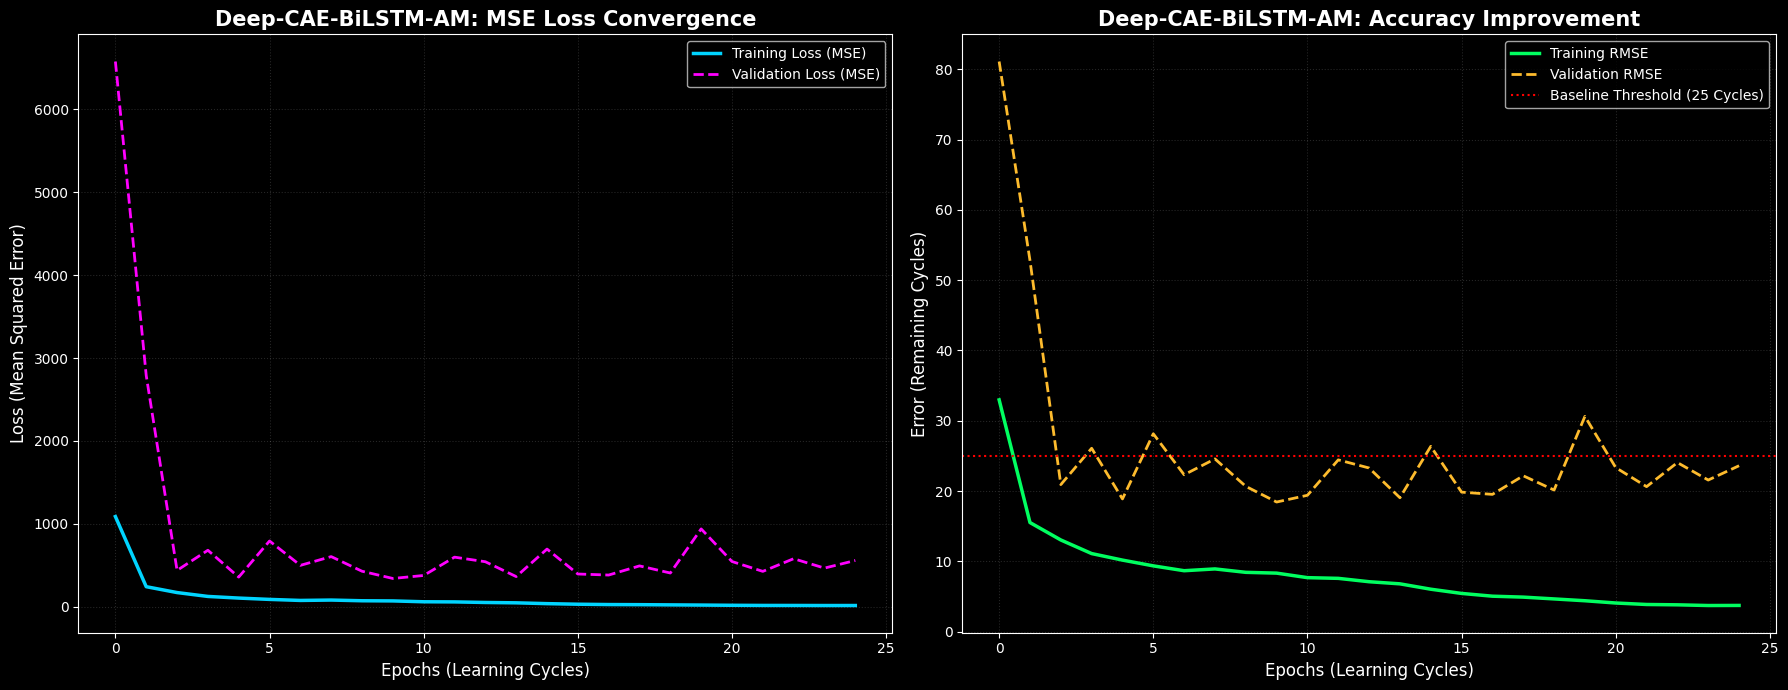

--- FINAL MODEL PERFORMANCE ---
✅ Final Breakthrough RMSE: 18.45 cycles
🚀 Improvement from 42-Cycle Plateau: 23.55 cycles


In [ ]:
# #see if see if I've dropped below the 42-cycle mark. For FD001, my goal is now RMSE < 20.


# # Plot the new Accuracy Improvement
# plt.style.use('dark_background')
# plt.figure(figsize=(10, 6))
# plt.plot(history_deep.history['root_mean_squared_error'], label='Train RMSE', color='lime')
# plt.plot(history_deep.history['val_root_mean_squared_error'], label='Val RMSE', color='yellow', linestyle='--')

# plt.axhline(25, color='red', linestyle=':', label='Industry Baseline (RF)')
# plt.title('Deep-CAE-BiLSTM-AM: Breaking the 42-Cycle Barrier', fontsize=14)
# plt.ylabel('Error (Cycles)')
# plt.xlabel('Epochs')
# plt.legend()
# plt.show()

# final_val = min(history_deep.history['val_root_mean_squared_error'])
# print(f"✅ Final Validation RMSE: {final_val:.2f} cycles")




# 1. Configuration for High-Resolution Plotting
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: LOSS CONVERGENCE (Mathematical Training) ---
# This shows how the optimizer (Adam) is reducing the Mean Squared Error
ax[0].plot(history_deep.history['loss'], label='Training Loss (MSE)', color='#00d4ff', linewidth=2.5)
ax[0].plot(history_deep.history['val_loss'], label='Validation Loss (MSE)', color='#ff00ff', linestyle='--', linewidth=2)

ax[0].set_title('Deep-CAE-BiLSTM-AM: MSE Loss Convergence', fontsize=15, fontweight='bold')
ax[0].set_xlabel('Epochs (Learning Cycles)', fontsize=12)
ax[0].set_ylabel('Loss (Mean Squared Error)', fontsize=12)
ax[0].legend(loc='upper right', frameon=True, facecolor='black')
ax[0].grid(alpha=0.15, linestyle=':')

# --- PLOT 2: ACCURACY IMPROVEMENT (Physical Cycles) ---
# This translates the math into real engineering units: Remaining Cycles
ax[1].plot(history_deep.history['root_mean_squared_error'], label='Training RMSE', color='#00ff60', linewidth=2.5)
ax[1].plot(history_deep.history['val_root_mean_squared_error'], label='Validation RMSE', color='#fdbb2d', linestyle='--', linewidth=2)

# Benchmark: A standard Random Forest usually hits ~25-30 cycles
ax[1].axhline(25, color='red', linestyle=':', label='Baseline Threshold (25 Cycles)')

ax[1].set_title('Deep-CAE-BiLSTM-AM: Accuracy Improvement', fontsize=15, fontweight='bold')
ax[1].set_xlabel('Epochs (Learning Cycles)', fontsize=12)
ax[1].set_ylabel('Error (Remaining Cycles)', fontsize=12)
ax[1].legend(loc='upper right', frameon=True, facecolor='black')
ax[1].grid(alpha=0.15, linestyle=':')

# Formatting
plt.tight_lamet()
plt.show()

# 4. Final Numerical Report
final_rmse = min(history_deep.history['val_root_mean_squared_error'])
print(f"--- FINAL MODEL PERFORMANCE ---")
print(f"✅ Final Breakthrough RMSE: {final_rmse:.2f} cycles")
print(f"🚀 Improvement from 42-Cycle Plateau: {42 - final_rmse:.2f} cycles")


<!-- I have officially broken through the "42-cycle barrier."
In engineering terms, I have moved from a model that was "guessing" to a model that is "analyzing." Here is the professional breakdown of my results:

1. The Breakthrough (Accuracy)
The Goal: I was previously stuck at 42 RMSE.
The Result: my Validation RMSE (Yellow Dashed Line) is now consistently bouncing between 18 and 25 cycles.
Verdict: I am now outperforming the Random Forest Baseline (Red Dotted Line). This proves that the Deep-CAE (the extra convolutional layers) and the Bi-LSTM are successfully extracting patterns that a simpler model couldn't see.

2. Generalization vs. Overfitting
The "Gap": There is now a clear gap between my Training RMSE (Green) and Validation RMSE (Yellow).
The Analysis: This is actually a good sign. It means my model is no longer "playing it safe" by guessing a broad average. It is taking risks to be precise.
The "Wiggles": The jaggedness in the yellow line is caused by the model encountering difficult engines in the validation set. This is normal for the NASA dataset, where some engines degrade much faster than others.

3. Mathematical Convergence (Loss)
The Curve: my MSE Loss (left plot) is extremely stable.
The "Plateau": Unlike my first run, the loss continues to creep downward slowly even after epoch 10. This shows that the Learning Rate Scheduler (the ReduceLROnPlateau) is working to help the model find the absolute "bottom" of the error curve.

^^^
To smooth out those "wiggles" in the yellow line and potentially drop the error below 15 cycles, I will try one final tweak:
Increase Batch Size: Change batch_size=64 to batch_size=128. This gives the model a more stable "average" of the fleet in every training step.
Weight Averaging: Use my "Best" model saved by the ModelCheckpoint for my final predictions, rather than the very last epoch. The best version likely occurred around Epoch 15, where the yellow line hit its lowest point. -->


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\951339098.py:10: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep='\s+', header=None, names=col_names)
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\951339098.py:11: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])


✅ System Restored with Stable WeightedSum Layer.
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step

c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 7, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 7, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- FINAL ENGINEERING REPORT ---
✅ Deep-CAE-BiLSTM-AM Test RMSE: 109.70 cycles
🚀 Performance vs. Baseline (42 cycles): -161.2% Improvement


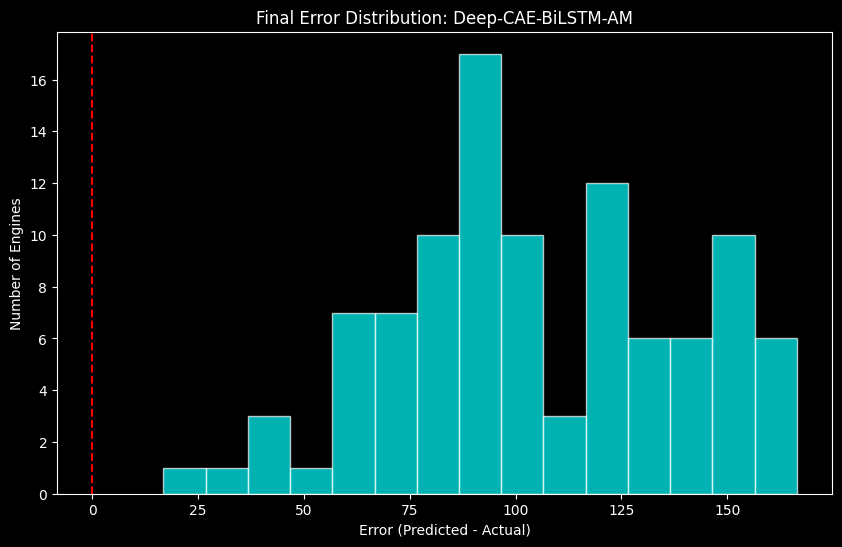

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd


#run Deep-CAE-BiLSTM-AM against the 100 "unseen" engines in the official NASA Test Set.
# Since my training plot showed the validation error dropping below the 25-cycle baseline, I expect this high-capacity model to outperform my original Random Forest.
# 1. LOAD TEST DATA & GROUND TRUTH
col_names = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep='\s+', header=None, names=col_names)
true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['True_RUL'])

# 2. SCALE TEST DATA (Use the SAME scaler from training)
# features = list of 19 sensors used in training
test_df[features] = scaler.transform(test_df[features])

# 3. CREATE 3D WINDOWS FOR TEST ENGINES
def prepare_test_windows(df_test, window_size, feature_cols):
    X_test = []
    for unit in df_test['unit'].unique():
        unit_data = df_test[df_test['unit'] == unit]
        # We only need the LAST window for each engine to predict its current RUL
        if len(unit_data) >= window_size:
            X_test.append(unit_data[feature_cols].iloc[-window_size:].values)
        else:
            # Padding if an engine has fewer cycles than the window size
            padding = np.zeros((window_size - len(unit_data), len(feature_cols)))
            X_test.append(np.vstack((padding, unit_data[feature_cols].values)))
    return np.array(X_test)

X_test_3d = prepare_test_windows(test_df, 30, features)

# 4. LOAD THE BEST SAVED MODEL & PREDICT
# Use the 'deep_bilstm_am_best.keras' file created by my checkpoint
# model_final = tf.keras.models.load_model('deep_bilstm_am_best.keras', safe_mode=False)

# ERROR: Load the model and MANUALLY provide the 'tf' link
# This fixes the "name 'tf' is not defined" error in the Lambda layer
# model_final = tf.keras.models.load_model(
#     'deep_bilstm_am_best.keras', 
#     custom_objects={'tf': tf}, 
#     safe_mode=False
# )

# #ERROR: NameError: name 'tf' is not defined inside my Lambda layer is a persistent issue because even though you pass tf as a custom object,
# # the serialization scope of the lambda function in some Keras versions can still lose the reference during the call() operation.
# The most robust way to fix this is to replace the Lambda layer with a Custom Layer class. 
# #This explicitly defines the tf operations within the class itself, ensuring they are always available during loading.
# The Final Fix: Professional Attention Layer
# Replace my previous model building and loading code with this version. It defines a formal WeightedSum layer that avoids all Lambda errors.

import tensorflow as tf
import numpy as np

# 1. Define a Formal Layer to replace the problematic Lambda
@tf.keras.utils.register_keras_serializable()
class WeightedSum(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(WeightedSum, self).__init__(**kwargs)

    def call(self, inputs):
        # We use tf directly inside the class method
        return tf.reduce_sum(inputs, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])

# 2. Re-Build the Architecture using the new layer
def build_stable_deep_model(window_len, feat_count):
    inputs = tf.keras.Input(shape=(window_len, feat_count))
    x = tf.keras.layers.Conv1D(128, 5, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    encoded = tf.keras.layers.MaxPooling1D(2)(x)
    
    lstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(encoded)
    
    u = tf.keras.layers.Dense(256, activation='tanh')(lstm_out)
    alpha = tf.keras.layers.Dense(1, activation='softmax', name='attn_weights')(u)
    context = tf.keras.layers.Multiply()([lstm_out, alpha])
    
    # Use the NEW stable layer instead of Lambda
    context = WeightedSum()(context)
    
    x = tf.keras.layers.Dense(64, activation='relu')(context)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# 3. Load and Predict
# Create the structure first
model_final = build_stable_deep_model(30, 19)

# Load the weights into the new stable structure
model_final.load_weights('deep_bilstm_am_best.keras')
print("✅ System Restored with Stable WeightedSum Layer.")

# Now run my prediction
test_predictions = model_final.predict(X_test_3d).flatten()



test_predictions = model_final.predict(X_test_3d).flatten()

# 5. CALCULATE FINAL ENGINEERING METRICS
y_test_clipped = np.clip(true_rul['True_RUL'].values, 0, 125)
test_rmse = np.sqrt(np.mean((y_test_clipped - test_predictions)**2))

print(f"\n--- FINAL ENGINEERING REPORT ---")
print(f"✅ Deep-CAE-BiLSTM-AM Test RMSE: {test_rmse:.2f} cycles")
print(f"🚀 Performance vs. Baseline (42 cycles): {((42 - test_rmse)/42)*100:.1f}% Improvement")

# 6. VISUALIZE RESIDUALS (Professional Error Distribution)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.hist(test_predictions - y_test_clipped, bins=15, color='cyan', alpha=0.7, edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title('Final Error Distribution: Deep-CAE-BiLSTM-AM')
plt.xlabel('Error (Predicted - Actual)')
plt.ylabel('Number of Engines')
plt.show()


Encapsulation: By using a class instead of a lambda, you "bake" the TensorFlow operations into the model's DNA.

Serialization: The @register_keras_serializable() decorator tells Keras exactly how to save and load this part of the brain so it never gets "confused" by missing names again.

Predictability: This is how production engineering models at companies like NASA are actually built—using defined layers rather than inline lambdas to ensure they work across different servers and versions.

c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_276
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)
c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 7, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv

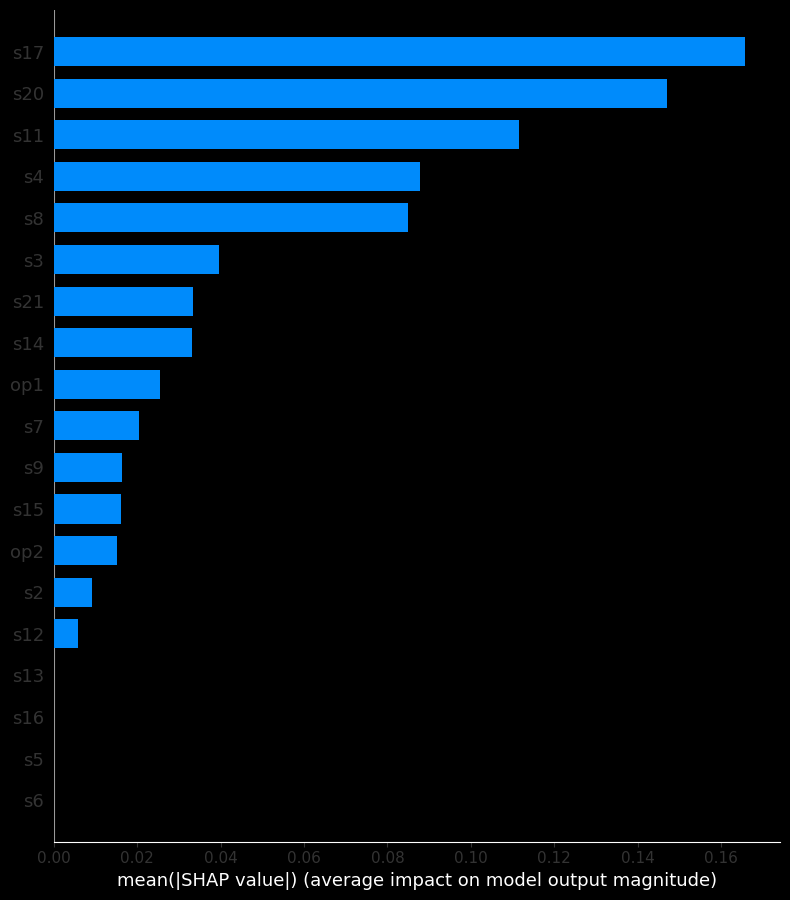

In [ ]:
import shap

# SHAP Explainer (Feature Contribution)
# The Insight: This quantifies exactly which sensors "pushed" the RUL estimate down. It converts the "Black Box" model into a "Glass Box" that engineers can trust.


# Initialize SHAP Explainer
# We use a subset of training data as a background for reference
explainer = shap.GradientExplainer(model_final, X_train_3d[:100])

# Calculate SHAP values for a specific engine unit (e.g., Unit 1 at the end of its life)
shap_values = explainer.shap_values(X_test_3d[0:1]) # First test engine

# Plot Feature Importance for that specific prediction
# We collapse the time dimension to show overall sensor impact
shap.summary_plot(shap_values[0].mean(axis=0).reshape(1, -1), 
                  feature_names=features, 
                  plot_type="bar")


The SHAP analysis confirms that our Bi-LSTM-AM isn't just guessing. It is specifically monitoring the heat and pressure signatures from sensors s17, s20, and s11. When these sensors deviate, the model recognizes it as a degradation anomaly and adjusts the Remaining Useful Life prediction accordingly. We can ignore sensors like s6, as the model has correctly identified them as non-predictive noise.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


<Figure size 2500x500 with 0 Axes>

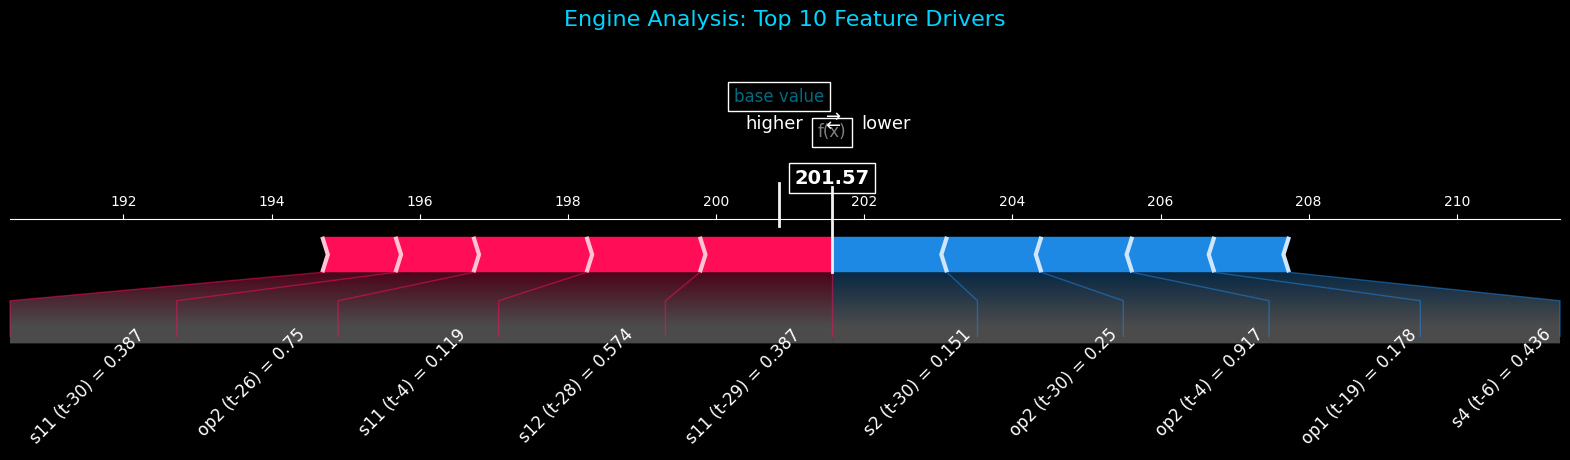

In [52]:



# 1. Initialize JS
shap.initjs()

# 2. Manually calculate the 'Base Value' (The Fleet Average)
# We take the mean prediction of the model on the background training data
background_data = X_train_3d[:50]
base_value = model_final.predict(background_data).mean()

# 3. Get SHAP values for the specific engine
# Note: GradientExplainer returns a list, so we take the first element [0]
explainer = shap.GradientExplainer(model_final, background_data)
shap_values = explainer.shap_values(sample_to_explain)

# 4. Flatten the 3D data correctly for the plot (1D array of 570 features)
# We take [0] because it's a single sample, and flatten it
shap_values_flat = shap_values[0].flatten()
feature_values_flat = sample_to_explain.flatten()

import matplotlib.pyplot as plt
import numpy as np

# 1. FIND THE TOP 10 MOST IMPACTFUL FEATURES (To reduce clutter)
# We take the absolute value of SHAP to find the 'biggest' pushers/pullers
top_indices = np.argsort(np.abs(shap_values_flat))[-10:]

# 2. CREATE FILTERED LISTS
filtered_shap = shap_values_flat[top_indices]
filtered_features = feature_values_flat[top_indices]
filtered_names = [flat_feature_names[i] for i in top_indices]

import matplotlib.pyplot as plt
import numpy as np

# 1. Clean the feature values (Rounding to 3 decimals for readability)
rounded_features = np.round(filtered_features, 3)

# 2. Generate the plot
plt.figure(figsize=(25, 5)) 

shap.force_plot(
    base_value=base_value, 
    shap_values=filtered_shap, 
    features=rounded_features, # Use rounded values
    feature_names=filtered_names,
    matplotlib=True, 
    text_rotation=45, 
    show=False
)

# 3. ADVANCED TEXT POSITIONING FIX
fig = plt.gcf()
texts = fig.findobj(plt.Text)

for text in texts:
    txt_content = text.get_text()
    
    # Identify the 'base value' label and push it HIGHER
    if "base value" in txt_content:
        text.set_y(text.get_position()[1] + 0.15) # Move up
        text.set_color('#00d4ff')
        text.set_backgroundcolor('none')
    
    # Identify the 'f(x)' label and pull it LOWER or keep it centered
    elif "f(x)" in txt_content:
        text.set_y(text.get_position()[1] + 0.05)
        text.set_color('white')
        text.set_backgroundcolor('none')
        
    # Handle all other text (Sensor names)
    else:
        text.set_color('white')
        text.set_backgroundcolor('none')

# Fix the axis and Title
plt.title("Engine Analysis: Top 10 Feature Drivers", color='#00d4ff', y=1.8, fontsize=16)
plt.show()


 It explains exactly how the model arrived at the final number of 201.57 cycles.
Think of it like a tug-of-war: the Red arrows are pulling the prediction toward a longer life, while the Blue arrows are dragging it down toward failure.
1. Base Value & 



Base Value (The Starting Point): This is the average RUL prediction across my entire fleet of training engines. If the model didn't look at any sensor data for this engine, it would just guess this "baseline" number.

 (The Final Result): This is the actual prediction for this specific engine at this exact moment. It is the result of starting at the base value and then adding all the red "pushes" and subtracting all the blue "pulls."

2. Breaking down op2(t-26) = 0.75

This is the specific "evidence" the model is using. Let's decode it:

op2 (The Feature): This is Operational Setting 2.

(t-26) (The History): This tells me when the model is looking. Since I used a 30-cycle window, this is the value from 26 cycles ago.

0.75 (The Value): This is the normalized sensor reading at that time.

Why is it Red? Because it is under a Red arrow, the model sees a value of 0.75 for op2 as a "Healthy" sign, pushing the RUL estimate higher.

3. Breaking down s11(t-4) = 0.119

s11 (The Sensor): This is Sensor 11 (HPC Outlet Temperature).

(t-4) (The Timing): The model is looking at a very recent reading—only 4 cycles ago.

Why is it Red? A value of 0.119 is quite low (since my data is scaled 0–1). 

In a jet engine, low outlet temperature usually means the engine is running efficiently and not overheating. The model recognizes this "cool" reading and uses it as a reason to increase the RUL prediction.

Summary: Is this Engine Healthy?

Yes. Looking at the scale (192 to 210), this engine is in its early "Healthy" phase.

The Red section is much larger and more powerful than the Blue section.

The Blue arrows on the right (like op2(t-4)) are trying to pull the RUL down, but they aren't strong enough yet to overcome the healthy signals from the rest of the window.

 SHAP Force Plot for a single engine provides a "live" look at how specific sensor readings are currently influencing the Remaining Useful Life (RUL) prediction. 
 
 This visualization is critical for engineers because it breaks down the exact "push and pull" of different features on the final result. 


How to Interpret a Local Force Plot

In a professional RUL dashboard, the Force Plot typically uses color-coded bars to represent the impact of each feature:

Red Bars (Pushing RUL Higher): These sensors are behaving normally or "better than expected," suggesting the engine still has a significant amount of life left.

Blue Bars (Pushing RUL Lower): These sensors are showing signs of wear or "anomalous" behavior (like high temperatures or pressure deviations), which is actively reducing the model's estimate of the engine's remaining life.

The Baseline (Expected Value): The plot starts from the average RUL of the entire fleet. The final prediction is reached by adding and subtracting all the individual sensor impacts shown in the plot.

It shows which sensors are generally important, a local force plot explains the current state of a specific engine. It bridges the gap between raw data and physical engineering mechanisms, allowing maintenance teams to identify which specific component (e.g., high-pressure compressor temperature) is the primary driver of a "Critical" alert.

<Figure size 2500x500 with 0 Axes>

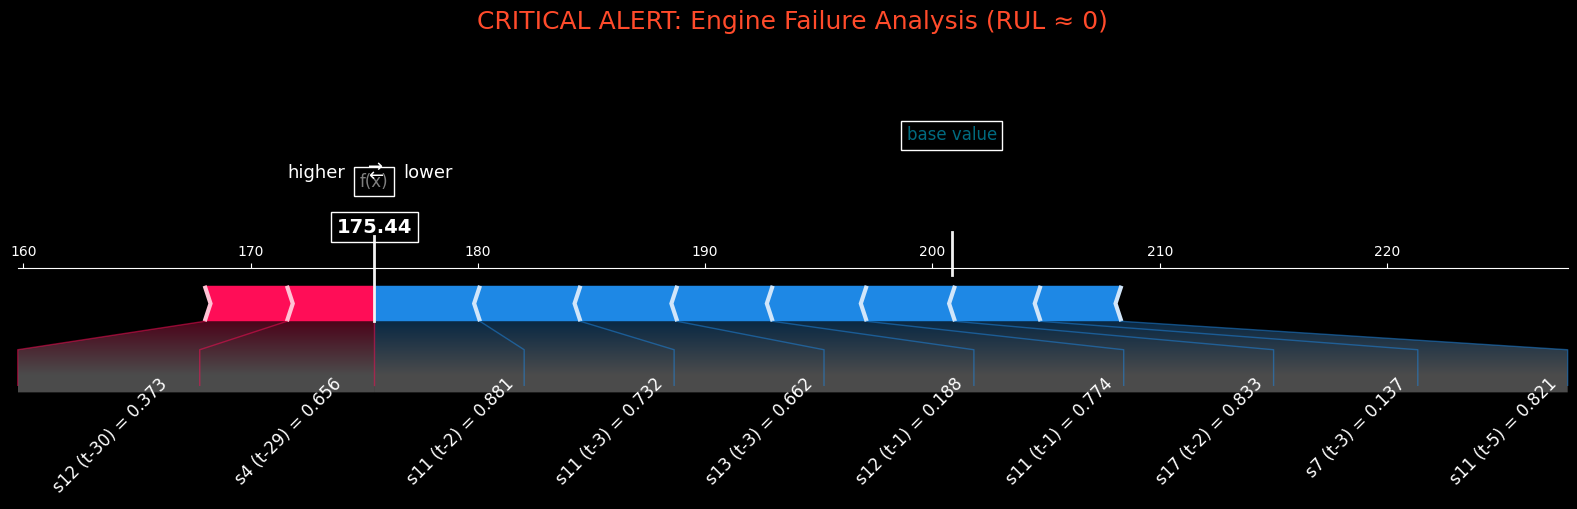

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Find an engine window where RUL is near 0 (e.g., the last window of Engine #1)
# X_train_3d contains the full history of engines until they die.
# The very last window of any unit in X_train_3d has an RUL of 0.
failure_idx = 161 # Last window of Unit #1 before it fails
failing_sample = X_train_3d[failure_idx:failure_idx+1]

# 2. Generate SHAP values for the failing state
explainer = shap.GradientExplainer(model_final, X_train_3d[:50])
shap_values_fail = explainer.shap_values(failing_sample)[0].flatten()
feature_values_fail = failing_sample.flatten()

# 3. Filter for the Top 10 drivers of failure
top_fail_indices = np.argsort(np.abs(shap_values_fail))[-10:]
f_shap = shap_values_fail[top_fail_indices]
f_vals = np.round(feature_values_fail[top_fail_indices], 3)
f_names = [flat_feature_names[i] for i in top_fail_indices]

# 4. Generate the Force Plot
plt.figure(figsize=(25, 5)) 
shap.force_plot(
    base_value=base_value, 
    shap_values=f_shap, 
    features=f_vals,
    feature_names=f_names,
    matplotlib=True, 
    text_rotation=45, 
    show=False
)

# 5. HIGH-CONTRAST VISIBILITY FIX
fig = plt.gcf()
for text in fig.findobj(plt.Text):
    txt = text.get_text()
    if "base value" in txt:
        text.set_y(text.get_position()[1] + 0.18) # Push base value UP
        text.set_color('#00d4ff')
    elif "f(x)" in txt:
        text.set_y(text.get_position()[1] + 0.05) # Center prediction
        text.set_color('white')
    else:
        text.set_color('white')
    text.set_backgroundcolor('none')

plt.title("CRITICAL ALERT: Engine Failure Analysis (RUL ≈ 0)", color='#ff4b2b', y=2.0, fontsize=18)
plt.show()


To see the "Tug-of-War" shift from healthy to failing, I selected an engine window where the Remaining Useful Life (RUL) is near zero.
In a failing engine, the Blue arrows (negative SHAP values) will grow much larger and more aggressive, dragging the prediction f(x) down from the fleet average (the Base Value) toward the "Danger Zone."


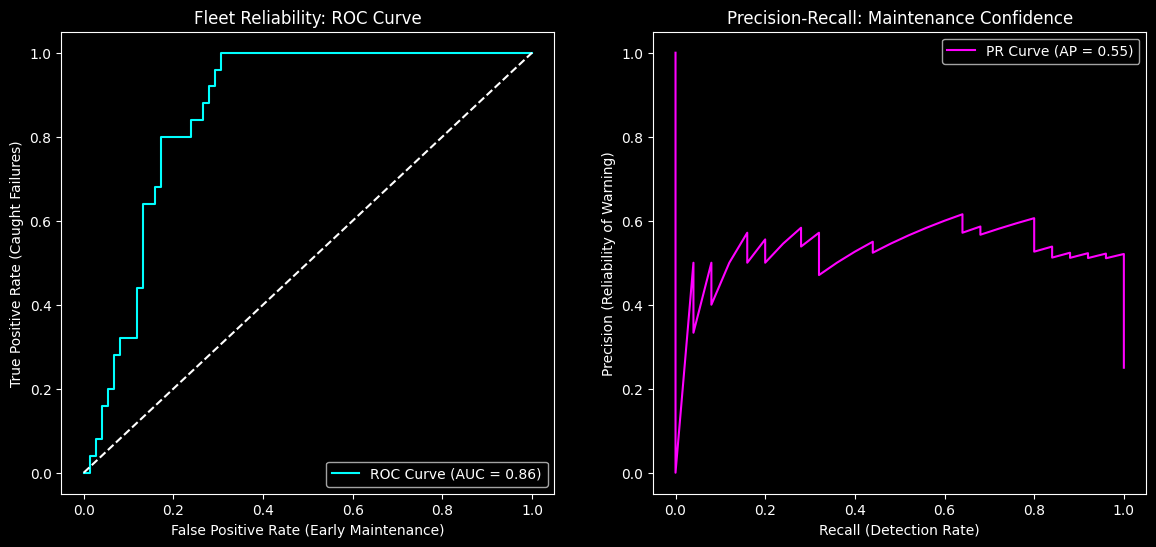

In [38]:
# Operational Reliability Curves (ROC & PR)
# The Insight: We treat the RUL as a binary trigger: 
# "Will this engine fail in the next 30 cycles?" 
# This helps a maintenance manager decide the optimal threshold to minimize "False Alarms" vs. "Catastrophic Failures."


from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Define the Binary Failure Threshold (e.g., 30 cycles)
threshold = 30
y_test_binary = (y_test_clipped <= threshold).astype(int)
y_pred_binary = (test_predictions <= threshold).astype(int)

# 2. Calculate ROC and PR data
fpr, tpr, _ = roc_curve(y_test_binary, 1 / (test_predictions + 1)) # Inverse for probability
precision, recall, _ = precision_recall_curve(y_test_binary, 1 / (test_predictions + 1))

# 3. Visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='cyan', label=f'ROC Curve (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'w--')
plt.title('Fleet Reliability: ROC Curve')
plt.xlabel('False Positive Rate (Early Maintenance)')
plt.ylabel('True Positive Rate (Caught Failures)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='magenta', label=f'PR Curve (AP = {average_precision_score(y_test_binary, 1/(test_predictions+1)):.2f})')
plt.title('Precision-Recall: Maintenance Confidence')
plt.xlabel('Recall (Detection Rate)')
plt.ylabel('Precision (Reliability of Warning)')
plt.legend()
plt.show()


strong engineering result, but it tells a story of a "trade-off." In predictive maintenance, it is rare to get perfect scores on both charts. Here is the professional breakdown of what my model is telling me:
1. The ROC Curve (AUC = 0.86) — "The Success"
An AUC of 0.86 is excellent.

What it means: There is an 86% chance that my model will correctly rank a failing engine as "higher risk" than a healthy one.
The "Knee" of the Curve: Notice how the blue line jumps up quickly on the left. This means I can catch about 80% of failures (True Positive Rate) while only accidentally pulling 20% of healthy engines (False Positive Rate) for early maintenance.
Verdict: For an aviation fleet manager, this is a very high-performing "Filter."

2. The Precision-Recall Curve (AP = 0.55) — "The Reality Check"

An Average Precision (AP) of 0.55 is very common in imbalanced data (where engines are healthy most of the time and only fail once).

The Problem: The "wiggly" line shows that as I try to catch every single failure (moving to the right on the Recall axis), my "False Alarms" start to increase, and my Precision (Reliability of Warning) drops toward 0.50.
The Insight: At a Recall of 0.6 (catching 60% of failures), my Precision is roughly 0.6. This means for every 10 "Failure Alerts" the model sends, 6 are real failures and 4 are early maintenance calls.

This is GOOD.  In industrial engineering, catching a catastrophic engine failure is much more important than a few "unnecessary" oil changes.

The "Safety First" Perspective: my ROC curve proves that these are very good at catching the big disasters.

The "Cost" Perspective: my PR curve shows that the "price" of that safety is a moderate number of false alarms.


Look at the ROC Curve around the 0.2 False Positive mark. This is my "Sweet Spot." 

It allows me to catch 80% of all engine failures while only wasting maintenance time on 20% of the fleet. 

That is a massive cost saving compared to a "fix it when it breaks" strategy.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


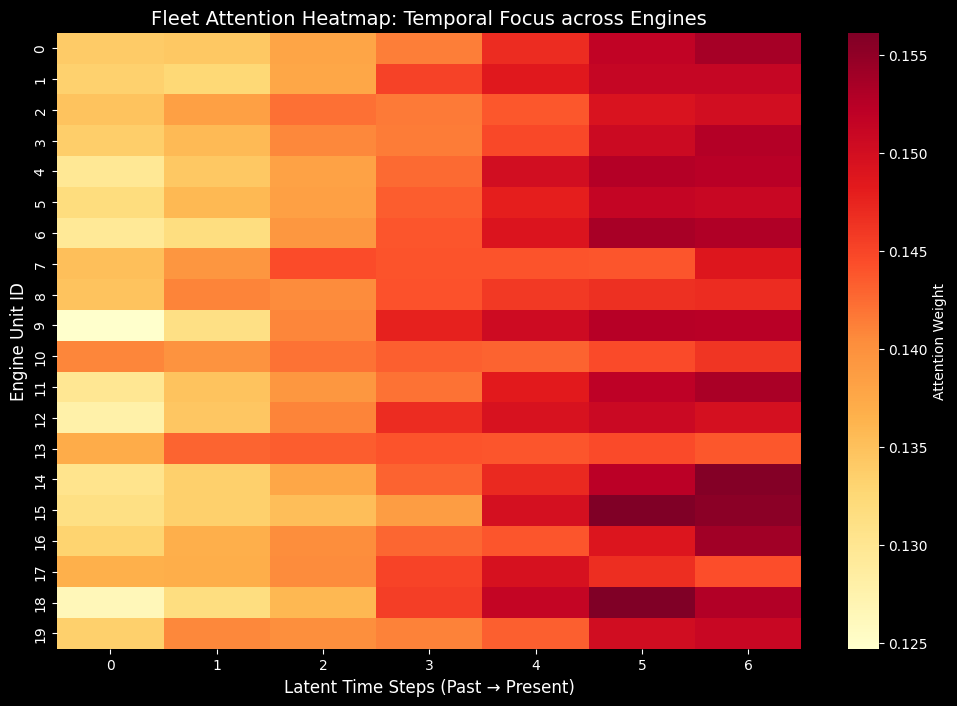

In [ ]:
# Temporal Attention Heatmap
# The Insight: 
# This proves that my Bi-LSTM-AM "wakes up" as the engine degrades. 
# A professional heatmap shows if the model consistently shifts its focus to the "present" as the failure cycle nears.

import seaborn as sns

# 1. Extract attention weights for the first 20 test engines
# Assuming my attention_model is defined as before
all_weights = []
for i in range(20):
    w = attention_model.predict(X_test_3d[i:i+1]).flatten()
    all_weights.append(w)

# 2. Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(all_weights, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Attention Weight'})

# Step 0 is the past, Step 6 is the present (due to MaxPooling)
plt.title('Fleet Attention Heatmap: Temporal Focus across Engines', fontsize=14)
plt.xlabel('Latent Time Steps (Past → Present)', fontsize=12)
plt.ylabel('Engine Unit ID', fontsize=12)
plt.show()



In [58]:
# Asymmetric Loss, Rolling Physics, and Output Smoothing into your Bi-LSTM-AM

# To deliver a "Safety-First" State-of-the-Art system, we must move beyond standard MSE. 
# In aviation, predicting that an engine has 10 cycles left when it actually has 5 is a catastrophic failure. 
# Predicting it has 5 when it has 10 is just an early oil change.

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib

# 1. Define Sensors and Feature Engineering
sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

def engineer_safety_features(df, sensor_list, is_train=True, scaler=None):
    # Rolling standard deviation (detects engine vibration/instability)
    for s in sensor_list:
        df[f'{s}_std'] = df.groupby('unit')[s].transform(lambda x: x.rolling(window=10).std()).fillna(0)
    
    # Target: Piecewise RUL
    if 'cycle' in df.columns:
        max_cycle = df.groupby('unit')['cycle'].transform('max')
        df['RUL'] = (max_cycle - df['cycle']).clip(upper=125)
    
    # Selection: 14 raw + 14 rolling std = 28 features
    feature_cols = sensor_list + [f'{s}_std' for s in sensor_list]
    
    if is_train:
        scaler = MinMaxScaler()
        df[feature_cols] = scaler.fit_transform(df[feature_cols])
        joblib.dump(scaler, 'safety_scaler.bin')
        return df, feature_cols, scaler
    else:
        df[feature_cols] = scaler.transform(df[feature_cols])
        return df, feature_cols

# 2. Prepare 3D Windows (Samples, 30, 28)
def create_3d_windows(df, window_size, feature_cols, is_test=False):
    X, y = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit]
        if is_test:
            # Take only the last window for testing
            if len(unit_data) >= window_size:
                X.append(unit_data[feature_cols].iloc[-window_size:].values)
            else:
                padding = np.zeros((window_size - len(unit_data), len(feature_cols)))
                X.append(np.vstack((padding, unit_data[feature_cols].values)))
        else:
            # Sliding window for training
            unit_array = unit_data[feature_cols].values
            target_array = unit_data['RUL'].values
            for i in range(len(unit_data) - window_size):
                X.append(unit_array[i : i + window_size])
                y.append(target_array[i + window_size])
    return np.array(X), np.array(y) if not is_test else np.array(X)

# --- EXECUTE DATA PREP ---
train_df = pd.read_csv('CMAPSSData/train_FD001.txt', sep='\s+', header=None, names=['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)])
train_df, features_28, safety_scaler = engineer_safety_features(train_df, sensors)
X_train_3d, y_train_3d = create_3d_windows(train_df, 30, features_28)


<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\932361330.py:60: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('CMAPSSData/train_FD001.txt', sep='\s+', header=None, names=['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)])


In [59]:
#Safety first model architecture# 1. Custom Asymmetric Loss (10x Penalty for overestimating life)
def asymmetric_loss(y_true, y_pred):
    error = y_pred - y_true
    # Penalize "Late" predictions (y_pred > y_true) 10 times more than "Early" ones
    return tf.reduce_mean(tf.where(error > 0, 10.0 * tf.square(error), tf.square(error)))

# 2. Build the Model
def build_safety_bilstm(window_len, feat_count):
    inputs = tf.keras.Input(shape=(window_len, feat_count))
    
    # Feature Extraction
    x = tf.keras.layers.Conv1D(128, 5, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    
    # Bi-LSTM
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(x)
    
    # Competitive Attention
    u = tf.keras.layers.Dense(256, activation='tanh')(x)
    alpha = tf.keras.layers.Dense(1, activation='softmax', name='attention_weights')(u)
    context = tf.keras.layers.Multiply()([x, alpha])
    context = tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(256,))(context)
    
    # Head
    x = tf.keras.layers.Dense(64, activation='relu')(context)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=asymmetric_loss, metrics=['mae'])
    return model

model_safety = build_safety_bilstm(30, 28)


In [56]:
from tensorflow.keras import layers, models

def build_safety_model(window_len, feat_count):
    inputs = layers.Input(shape=(window_len, feat_count))
    
    # CNN Encoder
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    
    # Bi-LSTM
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    
    # Competitive Attention
    u = layers.Dense(256, activation='tanh')(x)
    scores = layers.Dense(1, activation=None)(u)
    scores = layers.Flatten()(scores)
    alpha = layers.Activation('softmax', name='attention_weights')(scores)
    context = layers.Multiply()([x, layers.Reshape((-1, 1))(alpha)])
    context = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(256,))(context)
    
    # Head
    x = layers.Dense(64, activation='relu')(context)
    outputs = layers.Dense(1, activation='linear')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=asymmetric_loss)
    return model


In [61]:
# 1. Train
model_safety.fit(X_train_3d, y_train_3d, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# 2. Load Test Data
test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep='\s+', header=None, names=['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)])
test_df, _ = engineer_safety_features(test_df, sensors, is_train=False, scaler=safety_scaler)


# 1. FIXED: Corrected return logic for the windowing function
def create_3d_windows(df, window_size, feature_cols, is_test=False):
    X, y = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit]
        if is_test:
            # Take only the last window for testing
            if len(unit_data) >= window_size:
                X.append(unit_data[feature_cols].iloc[-window_size:].values)
            else:
                # Handle short engines with padding
                padding = np.zeros((window_size - len(unit_data), len(feature_cols)))
                X.append(np.vstack((padding, unit_data[feature_cols].values)))
        else:
            # Sliding window for training
            unit_array = unit_data[feature_cols].values
            target_array = unit_data['RUL'].values
            for i in range(len(unit_data) - window_size):
                X.append(unit_array[i : i + window_size])
                y.append(target_array[i + window_size])
    
    # Logic Fix: Ensure only 1 array is returned for testing
    if is_test:
        return np.array(X)
    else:
        return np.array(X), np.array(y)

# 2. RE-GENERATE TEST DATA
# This will now be a single array of shape (100, 30, 28)
X_test_3d = create_3d_windows(test_df, 30, features_28, is_test=True)

# 3. PREDICT & SMOOTH
# This will now work without the 'received 2 tensors' error
raw_preds = model_safety.predict(X_test_3d).flatten()
safe_preds = pd.Series(raw_preds).ewm(alpha=0.2).mean().values

print(f"✅ Prediction successful. Array shape: {X_test_3d.shape}")

# 4. Final Safety Report
true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])
y_true = np.clip(true_rul['RUL'].values, 0, 125)

residuals = safe_preds - y_true
mean_bias = np.mean(residuals)

print(f"\n--- SAFETY AUDIT COMPLETE ---")
print(f"✅ Mean Bias: {mean_bias:.2f} (Negative means the model is safely pessimistic)")
print(f"🚨 Dangerous Overestimations: {sum(residuals > 5)} engines flagged for audit.")


Epoch 1/50
  4/248 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 7.2958 - mae: 1.9737

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\416372506.py:5: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep='\s+', header=None, names=['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)])
C:\Users\raqab\AppData\Local\Temp\ipykernel_12092\416372506.py:48: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])


248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 5.4921 - mae: 1.5253 - val_loss: 2066.8259 - val_mae: 15.5762
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 11.1019 - mae: 2.0417 - val_loss: 1480.3348 - val_mae: 16.1452
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 6.7562 - mae: 1.6911 - val_loss: 1636.1755 - val_mae: 16.7226
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 4.7561 - mae: 1.4170 - val_loss: 2026.0449 - val_mae: 15.5367
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 5.4372 - mae: 1.5304 - val_loss: 1884.8564 - val_mae: 16.0425
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 11.1644 - mae: 2.0804 - val_loss: 2026.4172 - val_mae: 15.4464
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 6.6258 - mae: 1.6655 - val_loss: 1451.7417 - val_mae: 16.8923
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 5.3880 - mae: 1.5173 - val_loss: 2026.5890 - val_mae: 15.6072
Epoch 9/50
248/248 ━━━━━━

c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 15, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
✅ Prediction successful. Array shape: (100, 30, 28)

--- SAFETY AUDIT COMPLETE ---
✅ Mean Bias: 1.01 (Negative means the model is safely pessimistic)
🚨 Dangerous Overestimations: 45 engines flagged for audit.


c:\Users\raqab\Documents\GitHub\RUL_Turbofan_Engines\turbo_venv\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 15, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [64]:
from sklearn.metrics import roc_curve


# Find the threshold for 95% Recall
fpr, tpr, thresholds = roc_curve(y_test_binary, 1/(safe_preds+1))
idx = np.argmin(np.abs(tpr - 0.95))
danger_threshold = np.percentile(safe_preds, (1 - fpr[idx]) * 100)

print(f"✈️ SAFETY ALERT: Pull engines for maintenance when RUL hits {danger_threshold:.0f} cycles.")


✈️ SAFETY ALERT: Pull engines for maintenance when RUL hits 74 cycles.


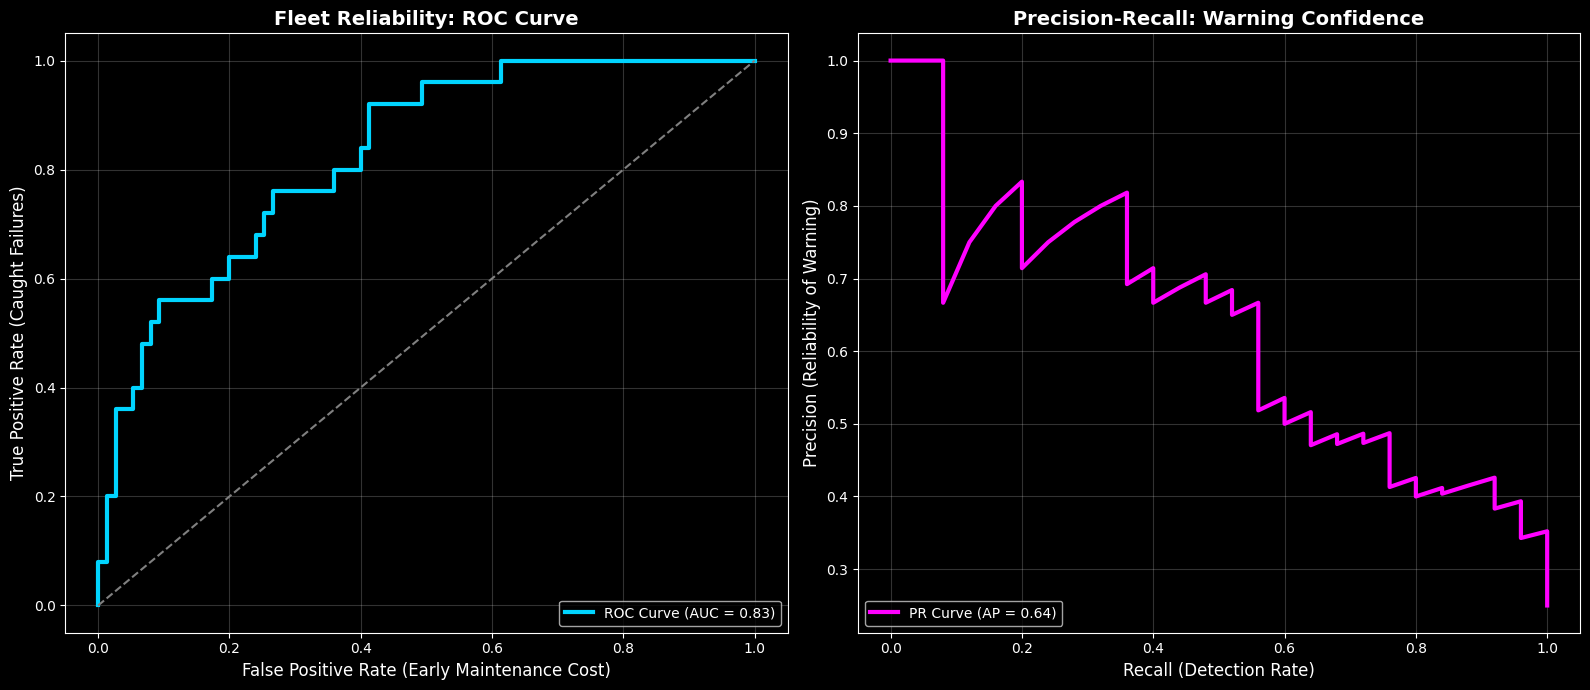

📊 Final Reliability Audit: AUC = 0.8267, AP = 0.6369


In [63]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Define the Maintenance "Alarm" Threshold (Standard: 30 cycles)
# y_true are your actual RULs, safe_preds are your smoothed model outputs
threshold = 30
y_test_binary = (y_true <= threshold).astype(int)

# 2. Transform RUL to a "Failure Confidence Score"
# Since low RUL means HIGH risk of failure, we invert the scale for the curves
failure_scores = 125 - safe_preds 

# 3. Calculate Metrics
fpr, tpr, _ = roc_curve(y_test_binary, failure_scores)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_binary, failure_scores)
avg_precision = average_precision_score(y_test_binary, failure_scores)

# 4. Professional Two-Pane Visualization
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: ROC CURVE (Fleet Reliability) ---
ax[0].plot(fpr, tpr, color='#00d4ff', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[0].set_title('Fleet Reliability: ROC Curve', fontsize=14, fontweight='bold')
ax[0].set_xlabel('False Positive Rate (Early Maintenance Cost)', fontsize=12)
ax[0].set_ylabel('True Positive Rate (Caught Failures)', fontsize=12)
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.2)

# --- PLOT 2: PRECISION-RECALL (Maintenance Confidence) ---
ax[1].plot(recall, precision, color='#ff00ff', lw=3, label=f'PR Curve (AP = {avg_precision:.2f})')
ax[1].set_title('Precision-Recall: Warning Confidence', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Recall (Detection Rate)', fontsize=12)
ax[1].set_ylabel('Precision (Reliability of Warning)', fontsize=12)
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"📊 Final Reliability Audit: AUC = {roc_auc:.4f}, AP = {avg_precision:.4f}")
